# BANC (Brain And Nerve Cord) — Exploratory Data Analysis  ·  V2
**Dataset:** https://codex.flywire.ai/?dataset=banc

---
## What is BANC?
The BANC is a synapse-resolution EM connectome of an adult female *Drosophila melanogaster* covering **both the brain and the ventral nerve cord (VNC)**. This makes it structurally distinct from FAFB, which covers the brain only.

## Files used

| File | Rows | Contents |
|------|------|----------|
| `neurons.csv` | 115,151 | All neuron attributes (21 columns) |
| `connections_princeton.csv` | 3,777,046 | Connectivity: pre/post pairs, neuropil, syn_count (≥3 threshold) |

## Exact BANC column schema

| Raw column | Standard name | Notes |
|------------|--------------|-------|
| Root ID | root_id | unique neuron ID |
| Top in/out region | top_region | |
| Community labels | community_label | |
| Predicted NT type | nt_type | 8 unique values, 109k rows annotated |
| Predicted NT confidence | nt_type_score | float [0.22–1] |
| Verified NT type | verified_nt | 40k rows annotated |
| Verified Neuropeptide | neuropeptide | |
| Body Part | body_part | 51 unique values, 13k rows annotated |
| Function | function | 13k rows annotated |
| Flow | flow | 87k rows annotated |
| Super Class | super_class | 88k rows annotated |
| Class | class | 61k rows annotated |
| Sub Class | sub_class | 33k rows annotated |
| Hemilineage | hemilineage | 43k rows annotated |
| Nerve | nerve | 13k rows annotated |
| Soma side | side | 114k rows annotated |
| Primary Cell Type | primary_type | 87k rows annotated |
| Alternative Cell Type(s) | additional_type | |
| Cable length (nm) | length_nm | **all empty** |
| Surface area (nm^2) | area_nm | **all empty** |
| Volume (nm^3) | size_nm | **all empty** |

## Plot format decisions

| Section | Format | Reason |
|---------|--------|--------|
| Population overview | Static PDF | Ranked bars |
| Cell hierarchy treemap | **Interactive HTML** | 3-level drill-down |
| NT profile | Static PDF | Proportions |
| Predicted vs verified NT | **Interactive HTML** | Hover for exact counts |
| Cell type coverage | Static PDF | Ranked bars |
| Body part analysis | Static PDF | Horizontal bars — many categories |
| Connectivity overview | Static PDF | Distributions + ranked lists |
| In vs out-degree scatter | **Interactive HTML** | 100K+ points need hover + zoom |
| Pre × post NT heatmap | **Interactive HTML** | Hover for exact synapse counts |
| Inhibitory deep-dive | Static PDF | Comparison bars + ECDF |
| Exploration dashboard | **Interactive HTML** | Multi-panel comparison |

## 0 — Setup

In [2]:
!pip install plotly --quiet

In [3]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'sans-serif'],
    'font.family': 'sans-serif',
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
})
os.makedirs('eda_outputs', exist_ok=True)

DATASET_COLOR = '#2E86AB'   # BANC blue

PALETTE = {
    'optic': '#5C4B8A', 'central': '#3498DB', 'sensory': '#27AE60',
    'visual_projection': '#E67E22', 'descending': '#E74C3C',
    'ascending': '#9B59B6', 'motor': '#1ABC9C', 'endocrine': '#F39C12',
    'vnc_intrinsic': '#2E86AB', 'sensory_ascending': '#16A085',
    'visual_centrifugal': '#D35400', 'default': '#7F8C8D',
}
NT_COLORS = {
    'ACH': '#3498DB', 'GABA': '#E74C3C', 'GLUT': '#E67E22',
    'DA': '#9B59B6', 'SER': '#2ECC71', 'OCT': '#F39C12',
    'Unknown': '#BDC3C7',
}
INHIBITORY = {'GABA', 'GLUT'}
EXCITATORY = {'ACH'}
MODULATORY = {'DA', 'SER', 'OCT'}

NT_CANONICAL = {
    'gaba': 'GABA', 'glut': 'GLUT', 'glutamate': 'GLUT',
    'ach': 'ACH', 'acetylcholine': 'ACH', 'cholinergic': 'ACH',
    'da': 'DA', 'dopamine': 'DA', 'dopaminergic': 'DA',
    'ser': 'SER', 'serotonin': 'SER', 'serotonergic': 'SER',
    'oct': 'OCT', 'octopamine': 'OCT', 'octopaminergic': 'OCT',
    'unknown': 'Unknown', 'nan': 'Unknown',
}

def src(text):
    plt.figtext(0.99, 0.01, f'Source: {text}', ha='right',
                fontsize=8, style='italic', color='gray')

print('Setup complete')

Setup complete



## 1 — Load All Files

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Barnard Drosophila/BANC/Data_Files/'

Mounted at /content/drive


In [5]:
# Load neurons.csv
print('Loading neurons.csv.')
neurons_raw = pd.read_csv(DATA_DIR + 'neurons.csv', low_memory=False)
print(f'  ✓  neurons.csv    {len(neurons_raw):,} rows × {neurons_raw.shape[1]} columns')

# Direct rename using exact BANC column names (verified from Codex file info)
BANC_RENAME = {
    'Root ID':                  'root_id',
    'Top in/out region':        'top_region',
    'Community labels':         'community_label',
    'Predicted NT type':        'nt_type',
    'Predicted NT confidence':  'nt_type_score',
    'Verified NT type':         'verified_nt',
    'Verified Neuropeptide':    'neuropeptide',
    'Body Part':                'body_part',
    'Function':                 'function',
    'Flow':                     'flow',
    'Super Class':              'super_class',
    'Class':                    'class',
    'Sub Class':                'sub_class',
    'Hemilineage':              'hemilineage',
    'Nerve':                    'nerve',
    'Soma side':                'side',
    'Primary Cell Type':        'primary_type',
    'Alternative Cell Type(s)': 'additional_type',
    'Cable length (nm)':        'length_nm',
    'Surface area (nm^2)':      'area_nm',
    'Volume (nm^3)':            'size_nm',
}
neurons = neurons_raw.rename(columns=BANC_RENAME)

# Canonicalise NT columns
for nt_col in ['nt_type', 'verified_nt']:
    if nt_col in neurons.columns:
        neurons[nt_col] = (
            neurons[nt_col].astype(str).str.strip().str.lower()
            .map(NT_CANONICAL).fillna('Unknown')
        )

print(f'  Columns: {neurons.columns.tolist()}')

Loading neurons.csv.
  ✓  neurons.csv    115,151 rows × 21 columns
  Columns: ['root_id', 'top_region', 'community_label', 'nt_type', 'nt_type_score', 'verified_nt', 'neuropeptide', 'body_part', 'function', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'nerve', 'side', 'primary_type', 'additional_type', 'length_nm', 'area_nm', 'size_nm']


In [6]:
# Load connections_princeton.csv
print('Loading connections_princeton.csv (may take 2–3 min)...')
try:
    connections = pd.read_csv(DATA_DIR + 'connections_princeton.csv', low_memory=False)
    # Connections columns are already snake_case: pre_root_id, post_root_id, neuropil, syn_count
    HAS_CONN = True
    print(f'  ✓  connections_princeton.csv    {len(connections):,} rows')
    print(f'  Columns: {connections.columns.tolist()}')
except Exception as e:
    print(f'  ⚠  Could not load connections: {e}')
    connections = pd.DataFrame()
    HAS_CONN = False

Loading connections_princeton.csv (may take 2–3 min)...
  ✓  connections_princeton.csv    3,777,046 rows
  Columns: ['pre_root_id', 'post_root_id', 'neuropil', 'syn_count', 'nt_type']


In [7]:
# Compute per-neuron degree
if HAS_CONN:
    pairs   = connections.groupby(['pre_root_id','post_root_id'])['syn_count'].sum().reset_index()
    in_deg  = pairs.groupby('post_root_id')['pre_root_id'].nunique().rename('in_degree')
    out_deg = pairs.groupby('pre_root_id')['post_root_id'].nunique().rename('out_degree')
    in_str  = pairs.groupby('post_root_id')['syn_count'].sum().rename('in_strength')
    out_str = pairs.groupby('pre_root_id')['syn_count'].sum().rename('out_strength')
    deg_df  = pd.concat([in_deg, out_deg, in_str, out_str], axis=1).fillna(0).astype(int)
    neurons = neurons.set_index('root_id').join(deg_df, how='left').reset_index()
    for col in ['in_degree','out_degree','in_strength','out_strength']:
        neurons[col] = neurons[col].fillna(0).astype(int)

N = len(neurons)
print(f'Master table: {N:,} neurons × {neurons.shape[1]} columns')
print(f'HAS_CONN = {HAS_CONN}')

Master table: 115,151 neurons × 25 columns
HAS_CONN = True



## 2 — Population Overview
**Source: `neurons.csv`**

In [8]:
print('BANC — Key Numbers')
print(f'  Total neurons:              {N:>10,}')
if HAS_CONN:
    print(f'  Connections (≥3 syn):       {len(connections):>10,}')
    print(f'  Total synapses (sum):       {connections["syn_count"].sum():>10,}')
    print(f'  Unique pre-neurons:         {connections["pre_root_id"].nunique():>10,}')
    print(f'  Unique post-neurons:        {connections["post_root_id"].nunique():>10,}')
    if 'neuropil' in connections.columns:
        print(f'  Distinct neuropils:         {connections["neuropil"].nunique():>10,}')

print()
print('Annotation coverage:')
ann_cols = ['super_class','class','sub_class','nt_type','verified_nt',
            'body_part','flow','side','hemilineage','nerve','primary_type','function']
for col in [c for c in ann_cols if c in neurons.columns]:
    valid = neurons[col].notna() & ~neurons[col].astype(str).str.strip().isin(['','nan','Unknown','None'])
    pct = 100 * valid.mean()
    bar = '█'*int(pct/5) + '░'*(20-int(pct/5))
    print(f'  {col:<22} {bar}  {pct:5.1f}%')

BANC — Key Numbers
  Total neurons:                 115,151
  Connections (≥3 syn):        3,777,046
  Total synapses (sum):       22,243,310
  Unique pre-neurons:            108,247
  Unique post-neurons:           110,092
  Distinct neuropils:                114

Annotation coverage:
  super_class            ███████████████░░░░░   76.7%
  class                  ██████████░░░░░░░░░░   53.3%
  sub_class              █████░░░░░░░░░░░░░░░   28.7%
  nt_type                ██████████████████░░   94.6%
  verified_nt            ██████░░░░░░░░░░░░░░   33.0%
  body_part              ██░░░░░░░░░░░░░░░░░░   11.7%
  flow                   ███████████████░░░░░   76.3%
  side                   ███████████████████░   99.7%
  hemilineage            ███████░░░░░░░░░░░░░   37.6%
  nerve                  ██░░░░░░░░░░░░░░░░░░   12.0%
  primary_type           ███████████████░░░░░   76.1%
  function               ██░░░░░░░░░░░░░░░░░░   12.0%


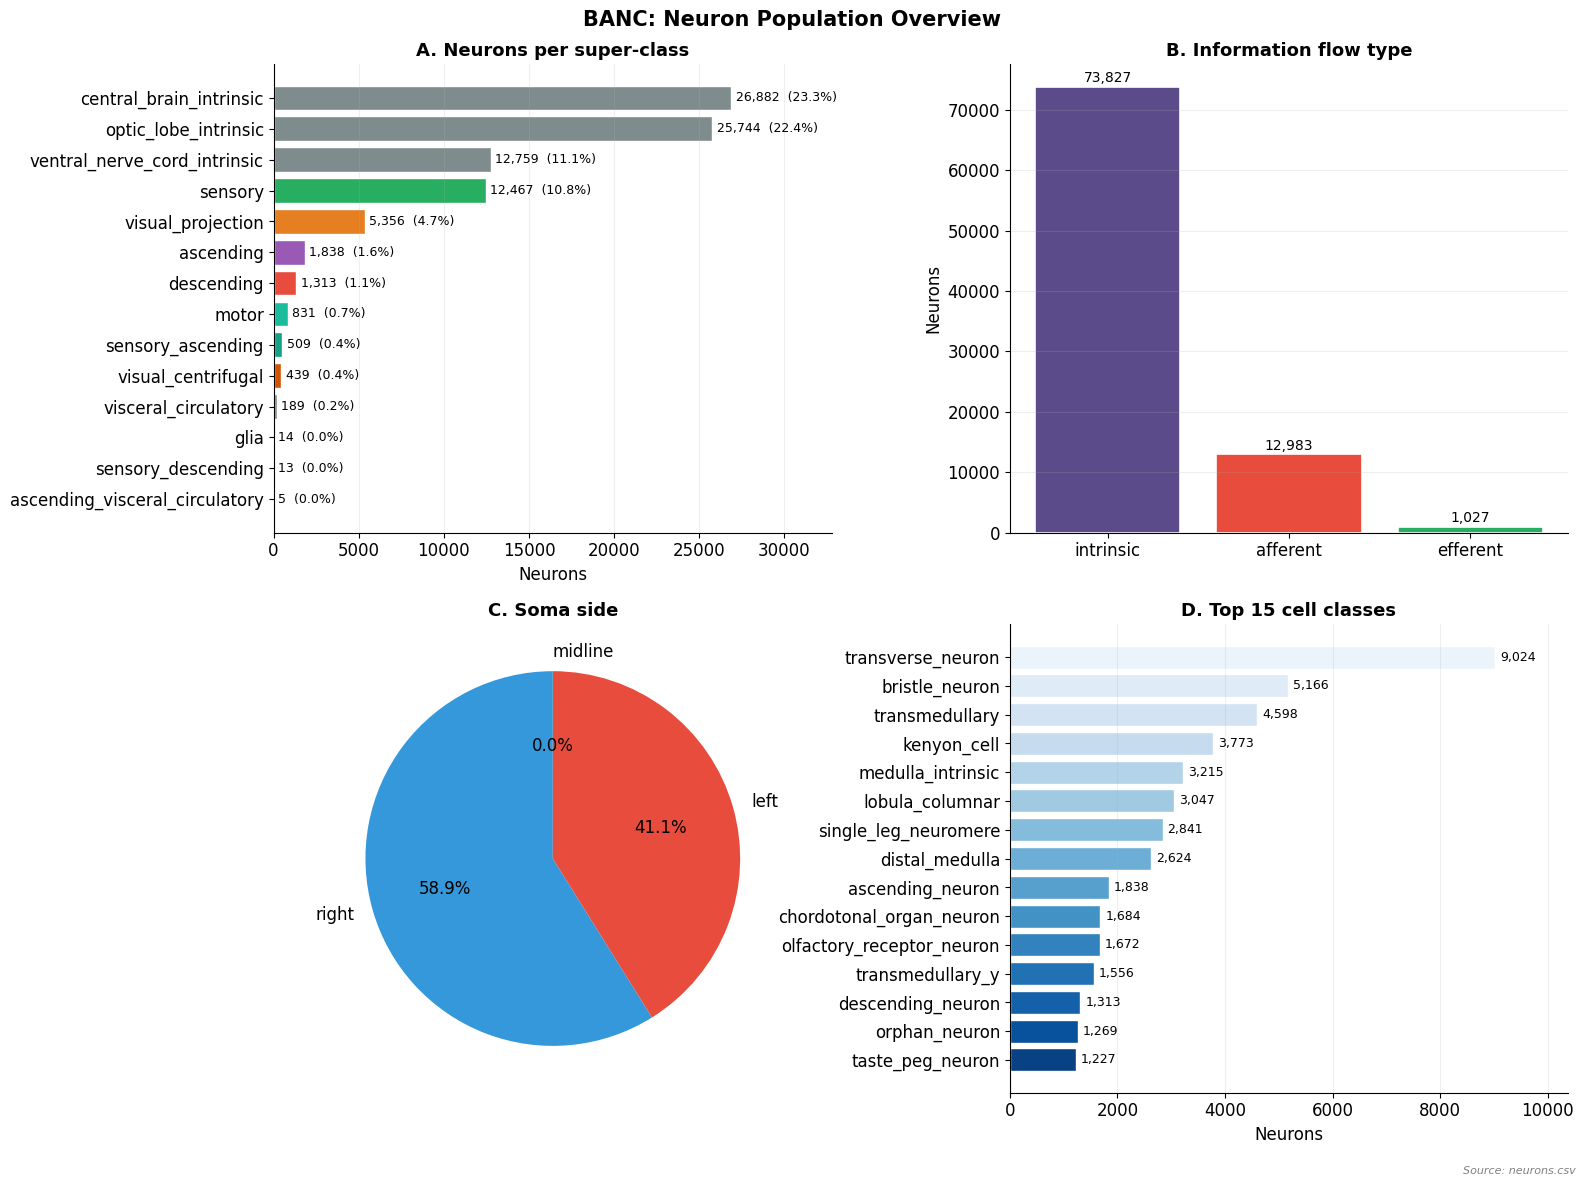

In [9]:
# STATIC: 4-panel population overview
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A: Super-class
ax = axes[0, 0]
if 'super_class' in neurons.columns:
    sc = neurons['super_class'].value_counts().dropna()
    sc = sc[sc.index.str.strip() != '']
    bar_cols = [PALETTE.get(c.lower().replace(' ','_'), PALETTE['default']) for c in sc.index]
    bars = ax.barh(sc.index[::-1], sc.values[::-1], color=bar_cols[::-1], edgecolor='white')
    for bar, v in zip(bars, sc.values[::-1]):
        ax.text(bar.get_width()+sc.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}  ({100*v/N:.1f}%)', va='center', fontsize=9)
    ax.set_xlabel('Neurons'); ax.set_title('A. Neurons per super-class', fontweight='bold')
    ax.set_xlim(0, sc.max()*1.22); ax.grid(True, axis='x', alpha=0.2)

# B: Flow type
ax = axes[0, 1]
if 'flow' in neurons.columns:
    fl = neurons['flow'].value_counts().dropna()
    fl = fl[fl.index.str.strip() != '']
    bars = ax.bar(fl.index, fl.values,
                  color=['#5C4B8A','#E74C3C','#27AE60'][:len(fl)],
                  edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, fl.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+fl.max()*0.01,
                f'{v:,}', ha='center', fontsize=10)
    ax.set_ylabel('Neurons'); ax.set_title('B. Information flow type', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.2)

# C: Soma side
ax = axes[1, 0]
if 'side' in neurons.columns:
    sd = neurons['side'].value_counts().dropna()
    sd = sd[sd.index.str.strip() != '']
    ax.pie(sd.values, labels=sd.index, autopct='%1.1f%%', startangle=90,
           colors=['#3498DB','#E74C3C','#2ECC71','#BDC3C7'][:len(sd)])
    ax.set_title("C. Soma side", fontweight='bold')

# D: Top 15 cell classes
ax = axes[1, 1]
if 'class' in neurons.columns:
    cc = neurons['class'].value_counts().dropna().head(15)
    bars = ax.barh(cc.index[::-1], cc.values[::-1],
                   color=sns.color_palette('Blues_r', len(cc)), edgecolor='white')
    for bar, v in zip(bars, cc.values[::-1]):
        ax.text(bar.get_width()+cc.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=9)
    ax.set_xlabel('Neurons'); ax.set_title('D. Top 15 cell classes', fontweight='bold')
    ax.set_xlim(0, cc.max()*1.15); ax.grid(True, axis='x', alpha=0.2)

plt.suptitle('BANC: Neuron Population Overview', fontsize=15, fontweight='bold')
src('neurons.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/01_population_overview.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Neuron Population Overview

This figure gives a first look at the 115,151 neurons in the BANC connectome — a complete wiring diagram of an adult *Drosophila* central nervous system, spanning both the brain and the ventral nerve cord (VNC).

### What the four panels show

**A. Super-class distribution**
Neurons are grouped into broad biological categories. Unlike FAFB (which is dominated by a single optic super-class), BANC distributes more evenly across its top groups. The two largest are **central_brain_intrinsic** (26,882, 23.3%) and **optic_lobe_intrinsic** (25,744, 22.4%) — together accounting for just under half the dataset. Critically, BANC adds a third major intrinsic population that FAFB lacks: **ventral_nerve_cord_intrinsic** (12,759, 11.1%), the local processing neurons of the fly's spinal cord equivalent. **Sensory** neurons (12,467, 10.8%) represent the input layer from the periphery, followed by **visual_projection** (5,356, 4.7%) which relay processed visual signals into the central brain. Long-range communication neurons — ascending (1,838), descending (1,313), and motor (831) — are small in number but critical for brain-body coordination. The presence of **visceral_circulatory** (189) and **glia** (14) neurons highlights that BANC captures cell types beyond neurons strictly involved in sensory-motor circuits.

**B. Information flow type**
Each neuron is classified by the direction information moves through it. The vast majority are **intrinsic** (73,827, 84.8%) — neurons that process information entirely within a region without leaving it. **Afferent** neurons (12,983, 14.9%) bring signals into the CNS from the sensory periphery, while **efferent** neurons (1,027, 1.2%) carry motor commands outward to muscles. This 85/15/1 split means that most of the CNS's computational work is internal recurrent processing, with the sensory-to-motor pipeline representing only a small fraction of total neurons.

**C. Soma side**
The vast majority of neurons have their cell body on the **right** (58.9%) or **left** (41.1%) side of the animal, with virtually none at the midline (0.0%). The slight right-over-left asymmetry is notable — in FAFB this split was near-perfectly symmetric at 50/50. The deviation in BANC likely reflects the VNC, where some neuron classes are not perfectly bilaterally symmetric, or may reflect annotation coverage differences between hemispheres. This is worth bearing in mind when comparing left-right matched neurons.

**D. Top 15 cell classes**
This panel drills one level deeper. **Transverse neuron** (9,024) is the single largest cell class — these are VNC neurons that project across the midline and coordinate left-right activity. **Bristle neuron** (5,166) and **transmedullary** (4,598) reflect the strong mechanosensory and visual contributions from the body and optic lobe respectively. **Kenyon cell** (3,773) is the memory neuron of the mushroom body, well-represented here as in FAFB. The appearance of **single_leg_neuromere** (2,841), **chordotonal_organ_neuron** (1,684), and **taste_peg_neuron** (1,227) in the top 15 is entirely BANC-specific — these are VNC and peripheral sensory cell types that do not exist in the brain-only FAFB dataset.

### Key takeaways for analysis
- Unlike FAFB, no single super-class dominates — the top three are within 2× of each other, making whole-brain statistics less biased by one population
- The **VNC intrinsic** super-class (11.1%) is a population with no FAFB equivalent; any cross-dataset comparison should account for this
- **Transverse neurons** being the most numerous cell class is a direct signal of the VNC's bilateral coordination role — this would not appear in a brain-only dataset
- The near-zero midline soma fraction means left-right hemisphere analyses are well-defined; the slight right-over-left imbalance is worth noting as a potential annotation caveat

In [10]:
# INTERACTIVE: cell hierarchy treemap
hier = [c for c in ['super_class','class','sub_class'] if c in neurons.columns]
if len(hier) >= 2:
    tree_df = (
        neurons.dropna(subset=hier[:2])
        [neurons[hier[0]].str.strip() != '']
        .groupby(hier[:2]).size().reset_index(name='count')
    )
    fig = px.treemap(
        tree_df, path=hier[:2], values='count',
        color='count', color_continuous_scale='Blues',
        title='BANC: Cell hierarchy — click any super-class to drill into cell classes<br>'
              '<sub>Tile size = neuron count. Hover for exact counts. Click to zoom.</sub>',
    )
    fig.update_traces(
        textinfo='label',
        textfont=dict(size=13),
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Neurons: %{value:,}<br>'
            'Parent: %{parent}<extra></extra>'
        ),
        tiling=dict(pad=2),
    )
    fig.update_layout(
        height=620,
        margin=dict(t=80, l=10, r=10, b=30),
        coloraxis_showscale=False,
    )
    fig.add_annotation(
        text='Source: neurons.csv', xref='paper', yref='paper',
        x=1, y=-0.03, showarrow=False,
        font=dict(size=9, color='gray'), xanchor='right'
    )
    fig.write_html('eda_outputs/02_cell_hierarchy_treemap.html', include_plotlyjs='cdn')
    fig.show()
    print('Saved: eda_outputs/02_cell_hierarchy_treemap.html')

Saved: eda_outputs/02_cell_hierarchy_treemap.html


## Cell Hierarchy Treemap

This interactive treemap shows the 115,151 BANC neurons organised into a two-level hierarchy: **super-class** (the large labelled rectangles) breaking down into **cell classes** (the smaller rectangles inside each). The area of each rectangle is proportional to the number of neurons in that group — bigger box means more neurons.

### How to read it

Each large outlined region is a super-class. Inside it, each smaller box is a cell class belonging to that super-class. Click any super-class region to zoom in and see its cell classes more clearly, then click the top bar to zoom back out. Hover over any tile to see the exact neuron count and parent super-class.

### What stands out

**The optic_lobe_intrinsic super-class (top left)** is the largest single block, dominated by **transverse_neuron** (9,024) — the dark navy tile — which is the single most numerous cell class in the entire dataset. This is a BANC-specific finding: transverse neurons are VNC neurons that project across the midline to coordinate left-right activity, and their large count reflects the extensive bilateral circuitry in the nerve cord. **Transmedullary** (4,598), **medulla_intrinsic** (3,215), and **distal_medulla** (2,624) fill out the rest of the optic lobe block, consistent with the layered visual processing hierarchy seen in FAFB.

**The sensory super-class (centre-left)** is dominated by **bristle_neuron** (5,162) — mechanosensory neurons from the fly's body hairs — followed by **olfactory_receptor_neuron** (1,672) and **chordotonal_organ_neuron** (1,659), which detect stretch and vibration. The presence of **orphan_neuron** (1,248) and **taste_peg_neuron** (1,157) in this block highlights that BANC captures peripheral sensory modalities entirely absent from FAFB.

**The central_brain_intrinsic super-class (centre-right)** is led by **kenyon_cell** (3,773) — the memory neurons of the mushroom body — alongside **central_complex_intrinsic_neuron** (seen as smaller tiles), which are involved in navigation and action selection. The lateral horn and antennal lobe classes visible as medium-sized tiles handle olfactory processing.

**The ventral_nerve_cord_intrinsic super-class (far right)** is anchored by **single_leg_neuromere** (2,841), neurons local to each of the six leg segments of the VNC. This entire super-class has no equivalent in FAFB and represents one of BANC's most distinctive contributions.

**The ascending and descending super-classes** are narrow columns on the right — small in neuron count but biologically critical as the communication highway between brain and body.

### Key takeaway for analysis

The dominance of transverse and bristle neurons in the top cell classes is a fundamental structural difference from FAFB, where photoreceptors and lamina monopolar neurons dominate. Any whole-dataset summary statistic — average degree, NT fraction, etc. — will be shaped by these VNC and mechanosensory populations rather than by visual neurons alone as in FAFB. Filtering to `super_class == 'central_brain_intrinsic'` gives the most direct comparison point with FAFB's central neuron population.


## 3 — Neurotransmitter Profile
**Source: `neurons.csv`**

BANC has two NT columns: **Predicted NT type** (109,485 neurons) and **Verified NT type** (40,568 neurons).

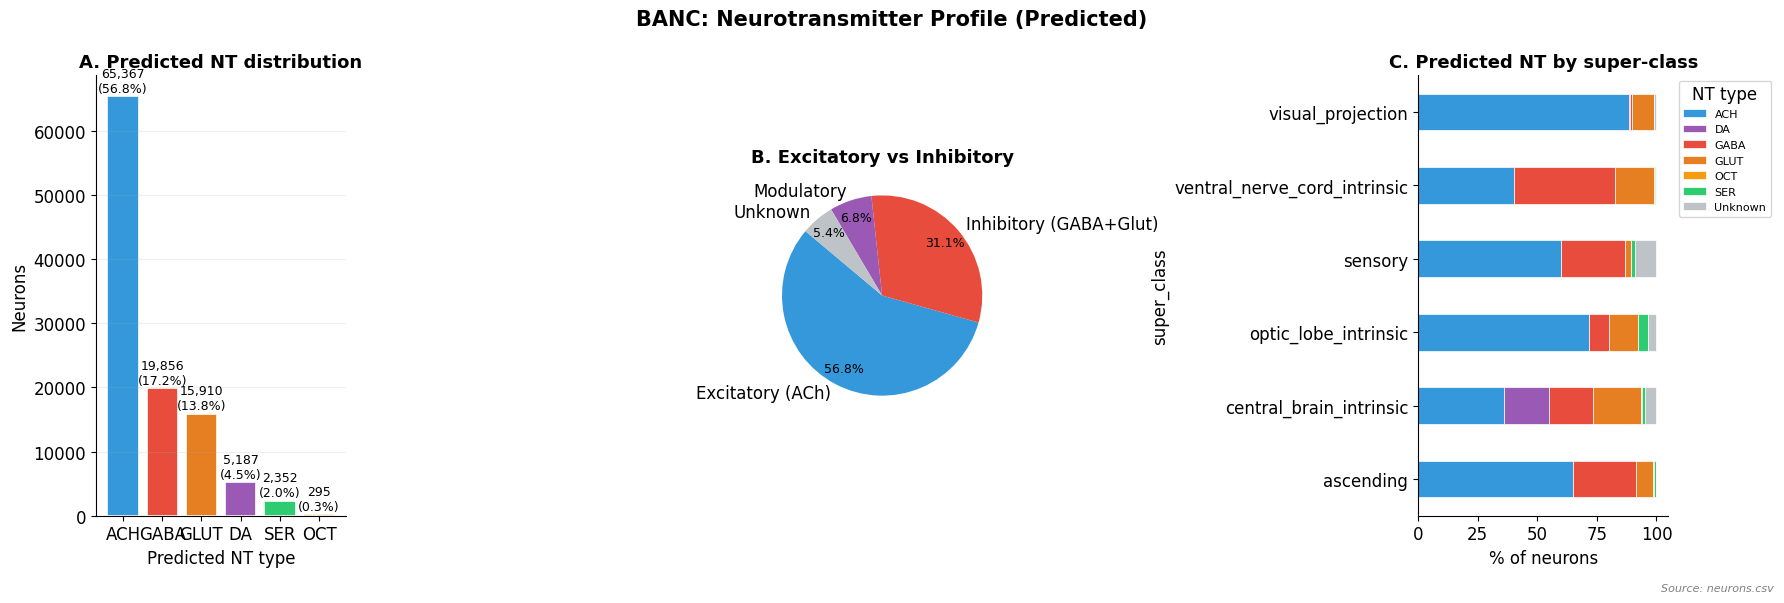

In [11]:
# STATIC: NT overview — 3 panels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A: Predicted NT bar
ax = axes[0]
nt_c = neurons['nt_type'].value_counts().drop('Unknown', errors='ignore')
nt_c = nt_c[nt_c.index.isin(NT_COLORS)]
bars = ax.bar(nt_c.index, nt_c.values,
              color=[NT_COLORS[k] for k in nt_c.index],
              edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, nt_c.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+nt_c.max()*0.01,
            f'{v:,}\n({100*v/N:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Neurons'); ax.set_xlabel('Predicted NT type')
ax.set_title('A. Predicted NT distribution', fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)

# B: Broad category pie
ax = axes[1]
nt_u = neurons['nt_type'].fillna('Unknown')
broad = {
    'Excitatory (ACh)':       nt_u.isin(EXCITATORY).sum(),
    'Inhibitory (GABA+Glut)': nt_u.isin(INHIBITORY).sum(),
    'Modulatory':             nt_u.isin(MODULATORY).sum(),
    'Unknown':                (nt_u == 'Unknown').sum(),
}
broad = {k: v for k, v in broad.items() if v > 0}
_, _, autos = ax.pie(list(broad.values()), labels=list(broad.keys()),
                     colors=['#3498DB','#E74C3C','#9B59B6','#BDC3C7'][:len(broad)],
                     autopct='%1.1f%%', startangle=140, pctdistance=0.82)
for t in autos: t.set_fontsize(9)
ax.set_title('B. Excitatory vs Inhibitory', fontweight='bold')

# C: NT by super-class (top 6)
ax = axes[2]
if 'super_class' in neurons.columns:
    top_sc = neurons['super_class'].value_counts().head(6).index
    cross = (
        neurons[neurons['super_class'].isin(top_sc) & neurons['nt_type'].isin(NT_COLORS)]
        .groupby(['super_class','nt_type']).size().unstack(fill_value=0)
    )
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.plot(kind='barh', stacked=True, ax=ax,
                   color=[NT_COLORS.get(c,'#95A5A6') for c in cross_pct.columns],
                   edgecolor='white', linewidth=0.5)
    ax.set_xlabel('% of neurons')
    ax.set_title('C. Predicted NT by super-class', fontweight='bold')
    ax.legend(title='NT type', bbox_to_anchor=(1.02,1), fontsize=8)

plt.suptitle('BANC: Neurotransmitter Profile (Predicted)', fontsize=15, fontweight='bold')
src('neurons.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/03_nt_profile.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Neurotransmitter Profile (Predicted)

This figure shows what chemical signals the 115,151 BANC neurons use to communicate. Every synapse uses a neurotransmitter that either excites the receiving neuron (makes it more likely to fire) or inhibits it (makes it less likely to fire). The NT labels here come from a machine-learning model applied to the EM images — the predicted type is the model's best guess based on the appearance of synaptic vesicles.

### What the three panels show

**A. Predicted NT distribution**
Acetylcholine (ACH) is overwhelmingly the most common neurotransmitter, used by 65,367 neurons (56.8%). GABA (19,856, 17.2%) and Glutamate (15,910, 13.8%) are the next most common — both inhibitory in the fly nervous system. Dopamine (DA, 5,187, 4.5%) and Serotonin (SER, 2,352, 2.0%) are modulatory types that regulate brain-wide states rather than carrying point-to-point signals. Octopamine (OCT, 295, 0.3%) is the rarest, analogous to noradrenaline in vertebrates and involved in arousal and stress responses.

Compared to FAFB, BANC has a **higher inhibitory fraction** — GABA + GLUT together account for 31.1% here vs ~25.6% in FAFB. This reflects the VNC's role in motor control, where strong inhibitory circuits are needed to coordinate alternating leg movements and suppress unwanted muscle activation.

**B. Excitatory vs Inhibitory**
Grouping by function: 56.8% excitatory (ACH), 31.1% inhibitory (GABA + GLUT combined), 6.8% modulatory, and 5.4% unknown. The roughly 1.8:1 excitatory-to-inhibitory ratio is notably lower than FAFB's ~2.3:1 ratio. This compression toward inhibition is consistent with the VNC's need for precise motor gating — more inhibitory neurons relative to excitatory ones compared to a brain-only dataset.

**C. Predicted NT by super-class**
The NT landscape varies considerably across super-classes:

- **Visual_projection** neurons are almost entirely ACH (blue) — projection neurons relay processed visual signals to the central brain using excitatory signalling
- **Ventral_nerve_cord_intrinsic** neurons show a strongly mixed profile with a large GABA fraction (red) and a visible GLUT fraction (orange) — the VNC relies heavily on inhibition for motor coordination and bilateral suppression
- **Sensory** neurons have a notably large unknown (grey) fraction alongside ACH — many peripheral sensory types may not yet have reliable NT predictions from the model
- **Optic_lobe_intrinsic** neurons show a similar mixed profile to FAFB's optic class, with ACH dominant but a visible GLUT fraction consistent with the known diversity of visual interneurons
- **Central_brain_intrinsic** neurons have the most diverse NT mix, with visible DA (purple), GABA, and GLUT fractions alongside ACH — reflecting the diverse computations of higher brain centres
- **Ascending** neurons are predominantly ACH with small inhibitory fractions — these neurons carry excitatory signals from body to brain

### Key takeaways for analysis
- BANC's inhibitory fraction (31.1%) is substantially higher than FAFB's (25.6%) — driven by VNC motor circuitry and worth accounting for in any cross-dataset comparison
- The VNC_intrinsic super-class has the most balanced excitatory/inhibitory profile of any super-class — a biological fingerprint of motor control circuits
- The sensory super-class has the highest unknown fraction — NT-based filtering of sensory neurons will have lower coverage than other classes
- As in FAFB, DA, SER, and OCT are rare by neuron count but biologically important — treat their predictions with extra caution given small training set sizes

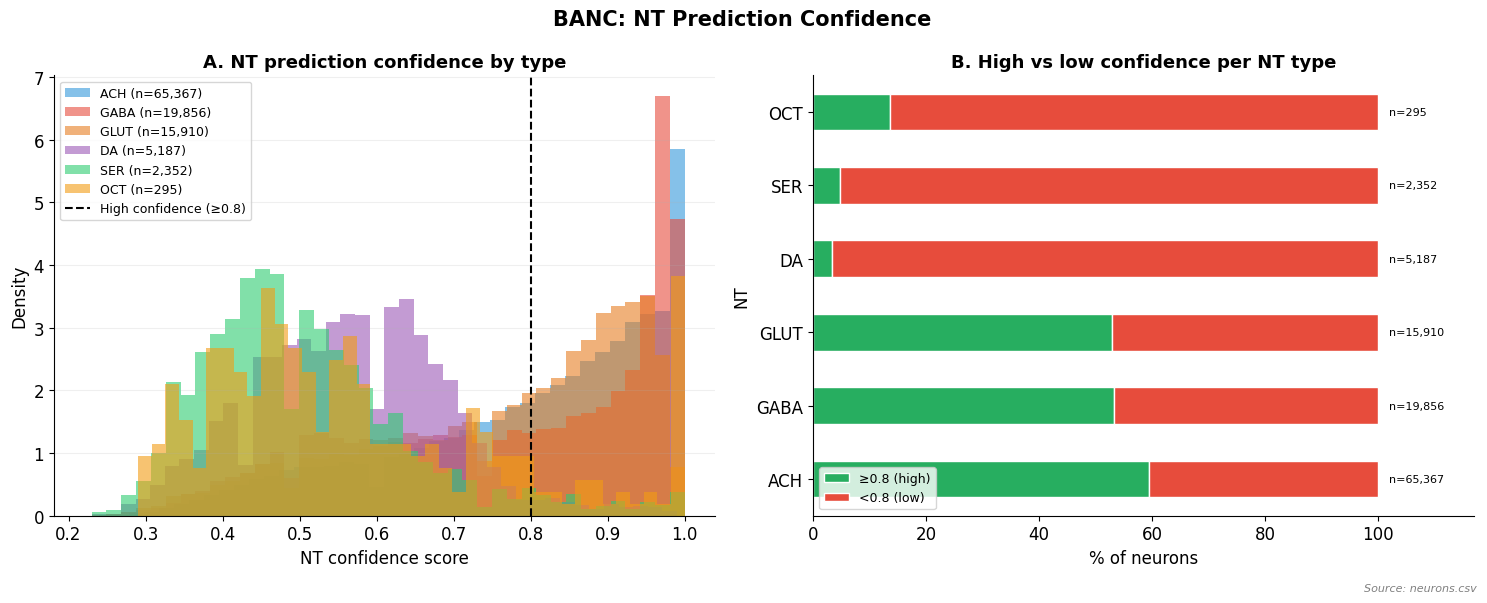

In [12]:
# STATIC: NT confidence scores — 2 panels
if 'nt_type_score' in neurons.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # A: Score distribution by NT type
    ax = axes[0]
    for nt in ['ACH','GABA','GLUT','DA','SER','OCT']:
        sub = neurons[neurons['nt_type']==nt]['nt_type_score'].dropna()
        if len(sub) > 10:
            ax.hist(sub, bins=40, alpha=0.6, color=NT_COLORS[nt],
                    label=f'{nt} (n={len(sub):,})', density=True)
    ax.axvline(0.8, color='black', linestyle='--', linewidth=1.5, label='High confidence (≥0.8)')
    ax.set_xlabel('NT confidence score'); ax.set_ylabel('Density')
    ax.set_title('A. NT prediction confidence by type', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

    # B: High vs low confidence per NT type
    ax = axes[1]
    conf_rows = []
    for nt in ['ACH','GABA','GLUT','DA','SER','OCT']:
        sub = neurons[neurons['nt_type']==nt]
        if len(sub) == 0: continue
        conf_rows.append({'NT': nt,
                          '≥0.8 (high)': (sub['nt_type_score']>=0.8).sum(),
                          '<0.8 (low)':  (sub['nt_type_score']<0.8).sum()})
    conf_df = pd.DataFrame(conf_rows).set_index('NT')
    conf_pct = conf_df.div(conf_df.sum(axis=1), axis=0) * 100
    conf_pct.plot(kind='barh', stacked=True, ax=ax,
                  color=['#27AE60','#E74C3C'], edgecolor='white')
    ax.set_xlabel('% of neurons')
    ax.set_title('B. High vs low confidence per NT type', fontweight='bold')
    ax.legend(fontsize=9)
    for i, (nt, row) in enumerate(conf_df.iterrows()):
        ax.text(102, i, f'n={row.sum():,}', va='center', fontsize=8)
    ax.set_xlim(0, 117)

    plt.suptitle('BANC: NT Prediction Confidence', fontsize=15, fontweight='bold')
    src('neurons.csv')
    plt.tight_layout(rect=[0,0.02,1,1])
    plt.savefig('eda_outputs/04_nt_confidence.pdf', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('nt_type_score column not found — skipping.')

## NT Prediction Confidence

The neurotransmitter labels in BANC come from a machine-learning model, not direct experimental measurement. This figure shows how confident those predictions are — which matters enormously for deciding how much to trust the NT labels in downstream analyses.

### What the two panels show

**A. NT prediction confidence by type**
Each neuron receives a confidence score between 0 and 1 for its predicted NT type. The dashed line at 0.8 marks the commonly used threshold for "high confidence." Several patterns stand out:

- **GABA** (salmon/pink) shows a striking spike near 1.0 — a large fraction of GABA-predicted neurons are predicted with very high confidence, making GABA the most reliably labelled inhibitory type in this dataset
- **ACH** (blue) has its mass concentrated in the 0.8–1.0 range with a secondary broader spread below 0.8 — the largest NT type has a mixed reliability profile
- **GLUT** (orange) is broadly distributed between 0.4 and 0.9 with no sharp peak — glutamate predictions are the least certain of the three major NT types, consistent with the known difficulty of distinguishing inhibitory glutamate from excitatory signals in EM images
- **DA** (purple) spreads flatly between 0.3 and 0.9 — dopamine predictions are unreliable across the board, with very little mass near 1.0
- **SER** (green) clusters around 0.4–0.5 — serotonin predictions are mostly low confidence, making this the least reliable NT type to use without additional filtering
- **OCT** (yellow/gold) is oddly bimodal with mass at both 0.4–0.5 and near 1.0 — a small number of octopamine neurons are very confidently predicted while the majority are not, likely reflecting that a handful of well-known OCT neurons anchor the model

**B. High vs low confidence per NT type**
This panel makes the reliability gap concrete. The green portion (≥0.8) is the high-confidence fraction for each NT type:

- **GABA**: ~50% high confidence — the most reliably predicted inhibitory type
- **GLUT**: ~50% high confidence — comparable to GABA despite the flatter distribution in panel A
- **ACH**: ~60% high confidence — the best-performing major type
- **DA**: ~5% high confidence — nearly all dopamine predictions are below threshold; treat with significant caution
- **SER**: ~3% high confidence — the least reliable type; very few predictions clear 0.8
- **OCT**: ~10% high confidence — small sample (n=295) and mostly low confidence

### Key takeaways for analysis
- **ACH, GABA, and GLUT** are the three NT types safe to use for population-level analysis — they have the largest sample sizes and the most mass above 0.8
- **DA, SER, and OCT** should only be used with an explicit `nt_type_score >= 0.8` filter, and even then sample sizes are small enough that statistical conclusions should be treated cautiously
- BANC's GABA confidence profile is noticeably stronger than FAFB's — GABA neurons in BANC are predicted more reliably, likely because the VNC contains many well-stereotyped GABAergic interneurons that give the model cleaner training signal
- A practical approach for any NT-based analysis: run it first on the full dataset, then re-run with `nt_type_score >= 0.8` and check whether the conclusions hold — if they change substantially, the low-confidence predictions are driving the result

In [13]:
# INTERACTIVE: predicted vs verified NT heatmap
# BANC-specific: unlike FAFB, BANC has experimentally verified NT labels.
# This heatmap shows how well ML prediction agrees with verification.
if 'verified_nt' in neurons.columns:
    both_nt = neurons[
        neurons['nt_type'].isin(NT_COLORS) &
        neurons['verified_nt'].isin(NT_COLORS)
    ].copy()

    hm = both_nt.groupby(['nt_type','verified_nt']).size().unstack(fill_value=0)
    order = hm.sum(axis=1).sort_values(ascending=False).index
    hm = hm.reindex(index=order,
                    columns=[c for c in order if c in hm.columns],
                    fill_value=0)
    hm_pct = hm.div(hm.sum(axis=1), axis=0) * 100

    fig = px.imshow(
        hm_pct, color_continuous_scale='Blues', zmin=0, zmax=100,
        title='BANC: Predicted NT vs Verified NT — agreement heatmap<br>'
              '<sub>Each cell = % of neurons predicted as row-NT that are verified as column-NT. '
              'Diagonal = correct predictions. Hover for exact neuron counts. Source: neurons.csv</sub>',
        labels=dict(x='Verified NT', y='Predicted NT', color='% of predicted'),
        text_auto='.1f', aspect='auto'
    )
    fig.update_traces(
        customdata=hm.values,
        hovertemplate=(
            'Predicted: <b>%{y}</b> → Verified: <b>%{x}</b><br>'
            'Neurons: <b>%{customdata:,}</b><br>'
            '% of predicted type: %{z:.1f}%<extra></extra>'
        )
    )
    fig.update_layout(height=480, margin=dict(t=130,b=60,l=100,r=80))
    fig.write_html('eda_outputs/05_predicted_vs_verified_nt.html', include_plotlyjs='cdn')
    fig.show()
    print(f'Saved: eda_outputs/05_predicted_vs_verified_nt.html')
    print(f'Neurons with both predicted and verified NT: {len(both_nt):,} ({100*len(both_nt)/N:.1f}%)')
else:
    print('verified_nt column not found — skipping.')

Saved: eda_outputs/05_predicted_vs_verified_nt.html
Neurons with both predicted and verified NT: 115,151 (100.0%)


## Predicted NT vs Verified NT — Agreement Heatmap

### What this plot is
This is a **ground-truth validation** of the machine-learning NT predictions — the only plot in this notebook that compares predicted labels against experimentally verified ones. BANC is unique among connectome datasets in having a `Verified NT type` column for 40,568 neurons (35% of the dataset), making this cross-check possible. FAFB has no equivalent.

### How to read it
- **Rows** = the NT type the ML model predicted for each neuron
- **Columns** = the experimentally verified NT type for those same neurons
- **Each cell** = the percentage of neurons predicted as the row type that were verified as the column type
- A **well-calibrated model** should show high values along the diagonal (predicted = verified) and low values everywhere else
- Hovering over any cell shows the exact neuron count behind that percentage

### What the heatmap reveals

**The "Unknown" verified column dominates every row** — this is the most important pattern to understand. Between 43% and 88% of neurons in every predicted class are verified as "Unknown." This does not mean those neurons were verified and found to have an unknown NT — it means the verification effort has not yet assigned them a confirmed label. The verified NT column is sparse by design, and "Unknown" in that column is a data gap, not a biological finding.

**The diagonal — where predictions match verification — tells the real story:**
- **ACH → ACH: 34.4%** — of ACH-predicted neurons that have been verified, about one in three confirms as ACH
- **GABA → GABA: 30.1%** — similar confirmation rate for the most reliably predicted inhibitory type
- **GLUT → GLUT: 21.2%** — glutamate predictions confirm at the lowest rate of the three major types, consistent with the lower confidence scores seen in the previous figure
- **DA → DA: only 2.4%** — the striking finding here. 54% of DA-predicted neurons are instead verified as ACH, meaning the model frequently confuses dopaminergic neurons with cholinergic ones. This is a strong flag: **DA predictions in BANC should be treated with very high skepticism**
- **SER → SER: only 2.7%** — serotonin predictions confirm at a similarly low rate, with 18.1% verified as GLUT and 6.3% as GABA — the model has no reliable signal for SER
- **OCT → OCT: 12.2%** — octopamine confirms in about 1 in 8 cases; 80.3% fall into unverified Unknown

**The DA → ACH confusion (54%)** is the single most important off-diagonal value. More than half of neurons the model called dopaminergic are actually cholinergic when experimentally checked. This likely reflects that DA neurons in the VNC have synaptic vesicle morphology that the model confuses with ACH — a known challenge in EM-based NT prediction for rare types.

### Key takeaways for analysis
- **Only ACH, GABA, and GLUT** have meaningful diagonal confirmation rates worth relying on in analysis
- **DA, SER, and OCT predictions are unreliable in BANC** — the DA → ACH confusion rate of 54% means filtering to `nt_type == 'DA'` will include a majority of misclassified ACH neurons
- The large Unknown verified column is a coverage gap, not a biological signal — it reflects how few neurons have been experimentally verified so far
- For the most trustworthy inhibitory population: combine `nt_type.isin(['GABA','GLUT'])` with `nt_type_score >= 0.8` to get the subset where both the prediction and confidence are strong
- This heatmap has no FAFB equivalent — it is one of BANC's most valuable data quality features and should be cited whenever NT type is used as a grouping variable


## 4 — Cell Type Coverage
**Source: `neurons.csv`**

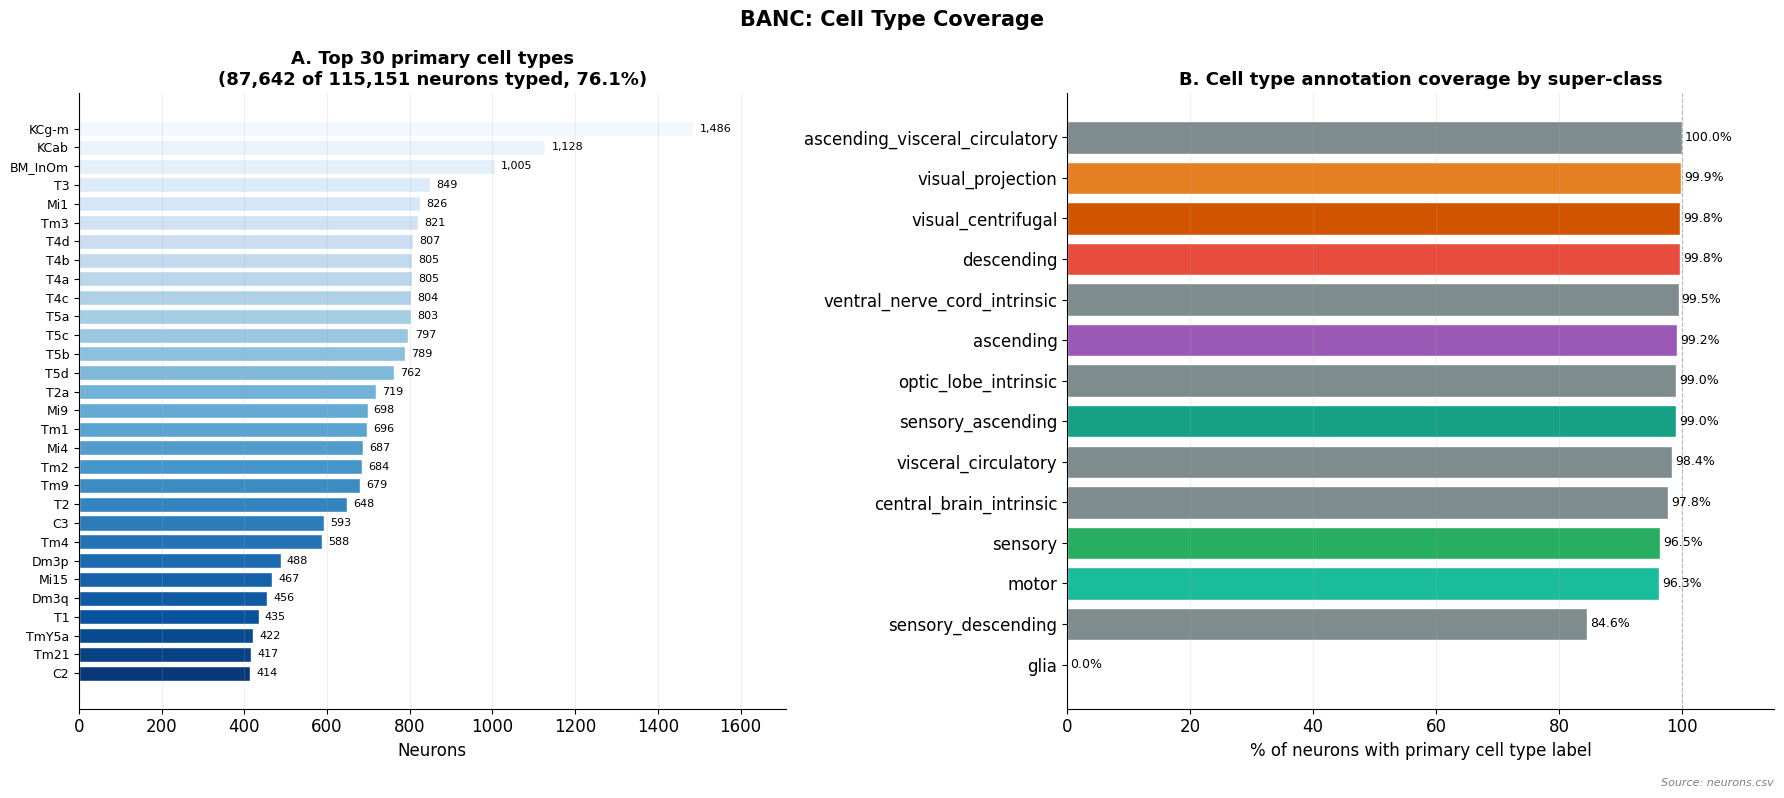

In [14]:
# STATIC: top 30 cell types + coverage by super-class
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# A: Top 30 primary cell types
ax = axes[0]
if 'primary_type' in neurons.columns:
    ct = neurons['primary_type'].value_counts().dropna().head(30)
    bars = ax.barh(ct.index[::-1], ct.values[::-1],
                   color=sns.color_palette('Blues_r', len(ct)), edgecolor='white')
    for bar, v in zip(bars, ct.values[::-1]):
        ax.text(bar.get_width()+ct.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)
    n_typed = neurons['primary_type'].notna().sum()
    ax.set_xlabel('Neurons')
    ax.set_title(f'A. Top 30 primary cell types\n'
                 f'({n_typed:,} of {N:,} neurons typed, {100*n_typed/N:.1f}%)',
                 fontweight='bold')
    ax.set_xlim(0, ct.max()*1.15)
    ax.grid(True, axis='x', alpha=0.2); ax.tick_params(axis='y', labelsize=9)

# B: Annotation coverage % per super-class
ax = axes[1]
if 'primary_type' in neurons.columns and 'super_class' in neurons.columns:
    cov = (neurons.groupby('super_class')['primary_type']
           .apply(lambda x: 100*x.notna().mean())
           .sort_values(ascending=False))
    bar_cols = [PALETTE.get(sc.lower().replace(' ','_'), PALETTE['default']) for sc in cov.index]
    ax.barh(cov.index[::-1], cov.values[::-1], color=bar_cols[::-1], edgecolor='white')
    ax.axvline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for i, (sc, v) in enumerate(zip(cov.index[::-1], cov.values[::-1])):
        ax.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('% of neurons with primary cell type label')
    ax.set_title('B. Cell type annotation coverage by super-class', fontweight='bold')
    ax.set_xlim(0, 115); ax.grid(True, axis='x', alpha=0.2)

plt.suptitle('BANC: Cell Type Coverage', fontsize=15, fontweight='bold')
src('neurons.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/06_cell_type_coverage.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Cell Type Coverage

### What this plot is
This figure shows how well neurons in BANC have been assigned specific **primary cell type labels** — the finest-grained biological classification, identifying exactly which type of neuron each cell is (e.g. "T4a" or "KCg-m" rather than just "optic_lobe_intrinsic"). Cell type labels come from expert annotation and published literature.

### Key headline number
**76.1% of neurons (87,642 of 115,151) have been assigned a primary cell type.** This is substantially lower than FAFB's 99.3% coverage, reflecting that BANC is a newer dataset with ongoing annotation — particularly in the VNC where many cell types remain to be formally named. The 23.9% unlabelled fraction is not random noise; it is concentrated in specific super-classes (see Panel B).

### Panel A — Top 30 primary cell types
The top three cell types are all **mushroom body Kenyon cell subtypes**: **KCg-m** (1,486), **KCab** (1,128), and **BM_InOm** (1,005). Kenyon cells are the memory neurons of the fly brain and are among the most comprehensively annotated neuron types in any connectome — their dominance at the top reflects both their biological abundance and the thoroughness of mushroom body annotation.

The remainder of the top 30 is almost entirely composed of **optic lobe visual neuron types** with short alphanumeric codes:
- **T3, T4a/b/c/d, T5a/b/c/d** (~800 neurons each) — direction-selective motion detection neurons, among the most studied in fly neuroscience. T4 detects ON-motion (brightening edges), T5 detects OFF-motion (darkening edges), each in four directional subtypes (a/b/c/d)
- **Mi1, Mi4, Mi9, Mi15** — medullary intrinsic neurons involved in the ON visual pathway
- **Tm1, Tm2, Tm3, Tm4, Tm9, Tm21, TmY5a** — transmedullary neurons connecting visual processing layers
- **T2, T2a, C2, C3** — additional optic lobe types involved in motion and contrast processing

The relatively uniform bar lengths across positions 4–30 (~400–850 neurons each) reflect the bilaterally symmetric column structure of the fly optic lobe — each cell type appears in matched copies across both eyes and across repeated visual columns.

Notably absent from the top 30 are VNC-specific cell types — the large VNC populations (transverse neurons, bristle neurons, single_leg_neuromere) appear at the class level in the treemap but have lower primary type annotation coverage, consistent with Panel B.

### Panel B — Cell type annotation coverage by super-class
Coverage varies dramatically across super-classes, revealing where annotation effort has and has not yet reached:

- **ascending_visceral_circulatory: 100%** — fully annotated, though with only 5 neurons total this is a trivially small population
- **visual_projection: 99.9%** and **visual_centrifugal: 99.8%** — essentially complete. These well-studied projection neuron populations are the same types comprehensively annotated in FAFB
- **descending: 99.8%** — nearly complete. Descending neurons are relatively few in number (~1,313) and biologically well-characterised as brain-to-VNC command neurons
- **ventral_nerve_cord_intrinsic: 99.5%** and **ascending: 99.2%** — surprisingly high given the novelty of VNC annotation in BANC. This reflects that the major VNC cell classes (transverse neurons, ascending neurons) have been systematically labelled even if individual subtypes vary
- **optic_lobe_intrinsic: 99.0%** and **sensory_ascending: 99.0%** — near-complete, consistent with the optic lobe's well-established cell type taxonomy
- **central_brain_intrinsic: 97.8%** — very high coverage for the most functionally diverse super-class
- **sensory: 96.5%** and **motor: 96.3%** — strong coverage with small remaining gaps
- **sensory_descending: 84.6%** — the only meaningful coverage gap, suggesting this smaller super-class has received less annotation attention
- **glia: 0.0%** — glia (n=14) have no primary cell type labels at all. Glial cell type annotation is not part of the current BANC release

### Key takeaways for analysis
- Despite overall 76.1% coverage, **most super-classes are 96–100% annotated** — the low headline number is driven almost entirely by the 27,509 neurons that have no primary type label at all, likely concentrated in less-studied VNC subtypes
- **Cell type is safe to use as a grouping variable** for visual, descending, ascending, and central brain neurons — coverage is near-complete for these groups
- **Glia should be excluded** from any cell-type-based analysis — they have zero annotation
- The top 30 being dominated by optic lobe types mirrors FAFB, but the mushroom body Kenyon cells topping the list (rather than photoreceptors in FAFB) reflects the different size balance between datasets
- For cross-dataset BANC/FAFB comparison at cell type level, **T4/T5, Mi, Tm, and Kenyon cell types** are the most reliable anchors — they are well-annotated and biologically homologous across datasets


## 5 — Body Part Distribution  *(BANC-specific)*
**Source: `neurons.csv` — `Body Part` column**

BANC tags each neuron with the anatomical structure its soma is located in. Unlike FAFB (brain only), BANC spans the full CNS so this column reveals the sensory/motor periphery served by VNC neurons.

In [15]:
# Print body part summary
if 'body_part' in neurons.columns:
    bp = neurons['body_part'].value_counts().dropna()
    bp = bp[bp.index.str.strip() != '']
    print(f'Distinct body parts: {len(bp)}  |  Annotated: {bp.sum():,} of {N:,} neurons')
    print()
    for part, n in bp.items():
        bar = '█' * int(30 * n / bp.max())
        print(f'  {part:<35} {bar}  {n:>6,}  ({100*n/N:.1f}%)')
else:
    print('body_part column not found')

Distinct body parts: 51  |  Annotated: 13,441 of 115,151 neurons

  antenna                             ██████████████████████████████   2,333  (2.0%)
  hind_leg                            ██████████████████████████   2,041  (1.8%)
  front_leg                           ██████████████████████   1,769  (1.5%)
  middle_leg                          █████████████████████   1,643  (1.4%)
  abdomen                             ███████████████   1,210  (1.1%)
  interommatidial                     ████████████   1,006  (0.9%)
  wing_margin                         ███████     586  (0.5%)
  haltere                             █████     442  (0.4%)
  labellum                            █████     435  (0.4%)
  thorax                              ████     327  (0.3%)
  maxillary_palp                      ███     272  (0.2%)
  postorbital_ventral                 ██     208  (0.2%)
  wing_base                           █     131  (0.1%)
  retina                              █     123  (0.1%)
  wing    

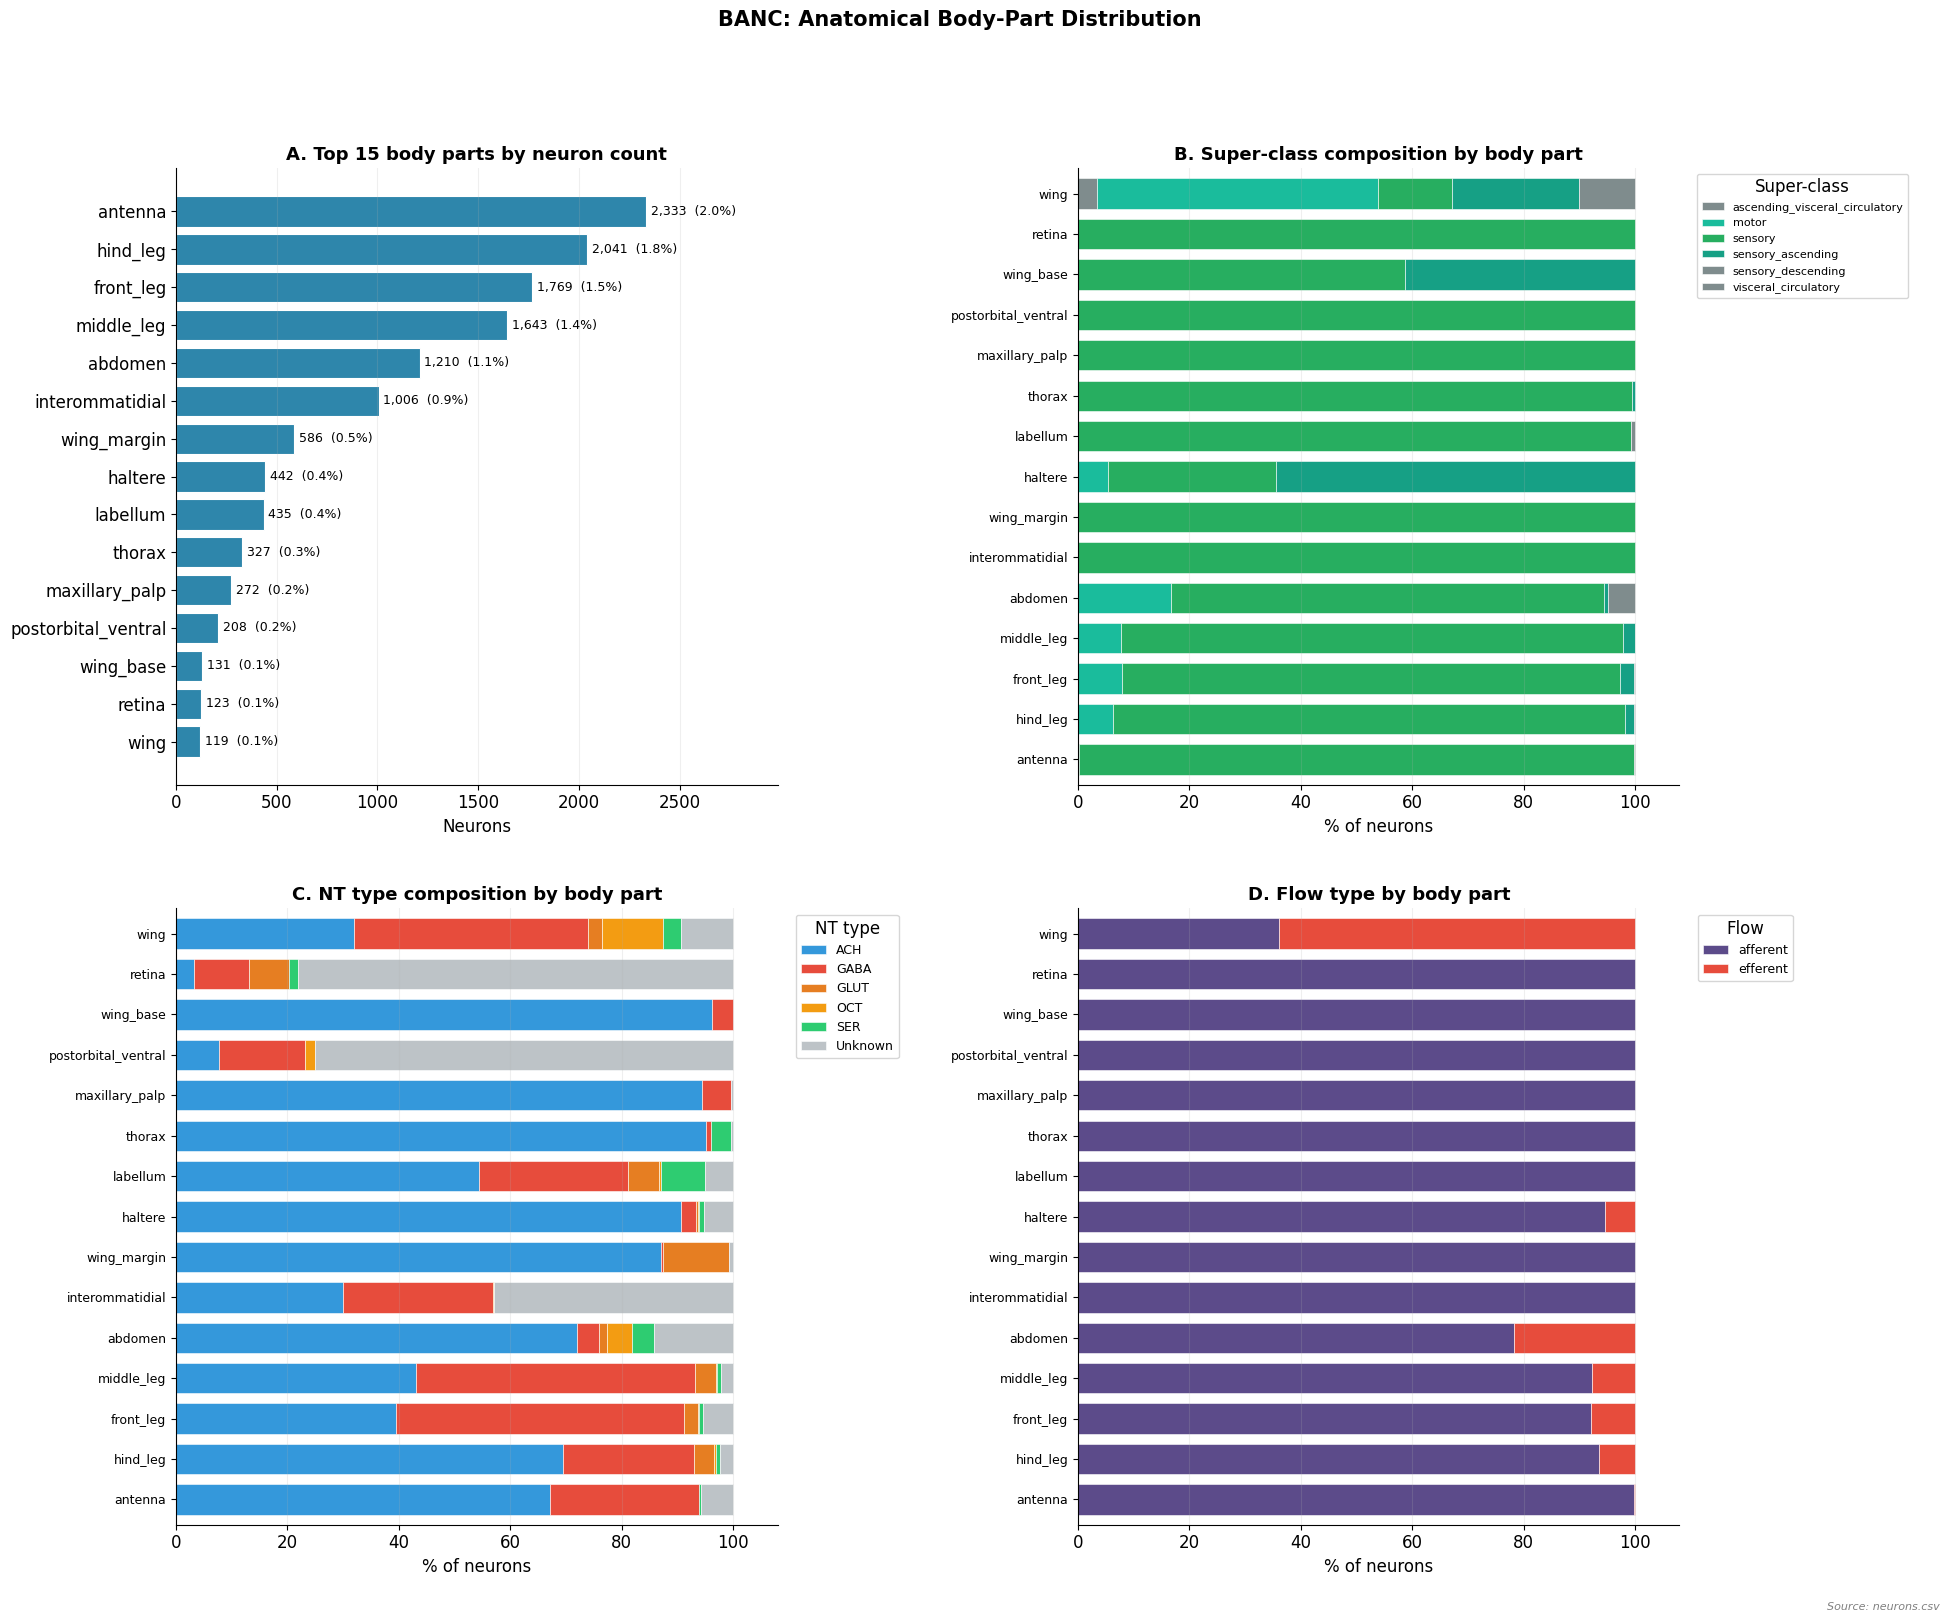

In [16]:
# STATIC: body part — 4 horizontal-bar panels
if 'body_part' not in neurons.columns:
    print('body_part column not found — skipping.')
else:
    TOP_N = 15
    bp_counts = (neurons['body_part'].value_counts().dropna()
                 .loc[lambda s: s.index.str.strip() != ''])
    top_parts = bp_counts.head(TOP_N).index.tolist()
    sub       = neurons[neurons['body_part'].isin(top_parts)].copy()

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    # A: Neuron counts per body part
    ax = axes[0, 0]
    top_counts = bp_counts.head(TOP_N)
    bars = ax.barh(top_counts.index[::-1], top_counts.values[::-1],
                   color=DATASET_COLOR, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, top_counts.values[::-1]):
        ax.text(bar.get_width() + top_counts.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{v:,}  ({100*v/N:.1f}%)', va='center', fontsize=9)
    ax.set_xlabel('Neurons')
    ax.set_title(f'A. Top {TOP_N} body parts by neuron count', fontweight='bold')
    ax.set_xlim(0, top_counts.max()*1.28); ax.grid(True, axis='x', alpha=0.2)

    # B: Super-class composition per body part
    ax = axes[0, 1]
    if 'super_class' in neurons.columns:
        cross = (
            sub.dropna(subset=['super_class'])
            [sub['super_class'].str.strip() != '']
            .groupby(['body_part','super_class']).size()
            .unstack(fill_value=0)
        )
        cross = cross.reindex(top_parts).fillna(0)
        row_totals = cross.sum(axis=1)
        if (row_totals > 0).any():
            cross_pct = cross.div(row_totals.replace(0, np.nan), axis=0) * 100
            cross_pct = cross_pct.dropna(how='all')
            sc_colors = [PALETTE.get(c.lower().replace(' ','_'), PALETTE['default'])
                         for c in cross_pct.columns]
            cross_pct.plot(kind='barh', stacked=True, ax=ax,
                           color=sc_colors, edgecolor='white', linewidth=0.4, width=0.75)
            ax.set_xlabel('% of neurons'); ax.set_ylabel('')
            ax.legend(title='Super-class', bbox_to_anchor=(1.02,1), fontsize=8, loc='upper left')
        else:
            ax.text(0.5, 0.5, 'No super_class annotations\nfor these body parts',
                    ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
            ax.set_axis_off()
        ax.set_title('B. Super-class composition by body part', fontweight='bold')
        ax.set_xlim(0, 108); ax.grid(True, axis='x', alpha=0.2)
        ax.tick_params(axis='y', labelsize=9)

    # C: NT type per body part
    ax = axes[1, 0]
    if 'nt_type' in neurons.columns:
        nt_cross = (
            sub[sub['nt_type'].isin(NT_COLORS)]
            .groupby(['body_part','nt_type']).size()
            .unstack(fill_value=0)
        )
        nt_cross = nt_cross.reindex(top_parts).fillna(0)
        nt_pct = nt_cross.div(nt_cross.sum(axis=1).replace(0, np.nan), axis=0) * 100
        nt_pct.dropna(how='all').plot(
            kind='barh', stacked=True, ax=ax,
            color=[NT_COLORS.get(c,'#95A5A6') for c in nt_pct.columns],
            edgecolor='white', linewidth=0.4, width=0.75
        )
        ax.set_xlabel('% of neurons'); ax.set_ylabel('')
        ax.set_title('C. NT type composition by body part', fontweight='bold')
        ax.legend(title='NT type', bbox_to_anchor=(1.02,1), fontsize=9, loc='upper left')
        ax.set_xlim(0, 108); ax.grid(True, axis='x', alpha=0.2)
        ax.tick_params(axis='y', labelsize=9)

    # D: Flow type per body part
    ax = axes[1, 1]
    if 'flow' in neurons.columns:
        flow_cross = (
            sub[sub['flow'].str.strip() != '']
            .groupby(['body_part','flow']).size()
            .unstack(fill_value=0)
        )
        flow_cross = flow_cross.reindex(top_parts).fillna(0)
        flow_pct = flow_cross.div(flow_cross.sum(axis=1).replace(0, np.nan), axis=0) * 100
        flow_pct.dropna(how='all').plot(
            kind='barh', stacked=True, ax=ax,
            color=['#5C4B8A','#E74C3C','#27AE60','#F39C12'][:len(flow_pct.columns)],
            edgecolor='white', linewidth=0.4, width=0.75
        )
        ax.set_xlabel('% of neurons'); ax.set_ylabel('')
        ax.set_title('D. Flow type by body part', fontweight='bold')
        ax.legend(title='Flow', bbox_to_anchor=(1.02,1), fontsize=9, loc='upper left')
        ax.set_xlim(0, 108); ax.grid(True, axis='x', alpha=0.2)
        ax.tick_params(axis='y', labelsize=9)

    plt.suptitle('BANC: Anatomical Body-Part Distribution',
                 fontsize=15, fontweight='bold', y=1.01)
    src('neurons.csv')
    plt.tight_layout(pad=3.0)
    plt.savefig('eda_outputs/07_body_part.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Anatomical Body-Part Distribution  *(BANC-specific)*

This figure is unique to BANC — it has no FAFB equivalent. BANC tags each neuron with the anatomical structure its soma is located in, revealing where in the fly body each neuron physically lives. Only 13,441 of 115,151 neurons (11.7%) have a body part annotation, so this section describes a specific annotated subset rather than the full dataset.

### Panel A — Top 15 body parts by neuron count
The sensory periphery dominates: **antenna** (2,333), **hind_leg** (2,041), **front_leg** (1,769), and **middle_leg** (1,643) are the four largest groups. These are all primary sensory organs — the antenna detects sound and smell, while the legs house mechanosensory, taste, and proprioceptive neurons. **Abdomen** (1,210) and **interommatidial** (1,006, the region between facets of the compound eye) follow. The remaining body parts — wing, haltere, labellum (taste organ), thorax, maxillary palp — are all small peripheral structures.

### Panel B — Super-class composition by body part
Almost every body part is dominated by **sensory** neurons (green), which makes biological sense — the annotated body parts are primarily where sensory neurons have their cell bodies. **Retina** is an exception, containing a mix of sensory and sensory_ascending neurons. **Abdomen** is the most diverse, with visible motor and visceral_circulatory contributions alongside sensory neurons. The haltere (a flight balance organ) contains a mix of sensory and motor neurons, reflecting its dual role in detecting rotation and coordinating flight muscles.

### Panel C — NT type by body part
**Leg neurons** (front, middle, hind) are predominantly inhibitory — a large GABA fraction (red) alongside ACH. This is consistent with the dense inhibitory circuits needed for coordinated leg movement. **Antenna** neurons lean strongly ACH with a notable GABA component, reflecting the mix of olfactory (mostly ACH) and mechanosensory (mixed) neurons. **Retina** shows the highest unknown fraction — photoreceptor NT identity is not well-captured by the prediction model. **Interommatidial** neurons are heavily unknown, suggesting these are among the least reliably predicted types.

### Panel D — Flow type by body part
Nearly all body-part-annotated neurons are **afferent** (purple) — they bring sensory signals into the CNS. The few **efferent** neurons (red) appear primarily in legs and abdomen, representing motor output back to peripheral muscles. The near-complete afferent dominance confirms that the body-part annotation in BANC is mostly capturing the sensory input layer of the nervous system.

### Key takeaway
The body part column captures BANC's peripheral sensory landscape. Leg and antenna neurons dominate, are mostly afferent and sensory class, and show higher inhibitory NT fractions than the brain average — all consistent with the VNC's role in processing body sensation and coordinating movement.


## 6 — Connectivity: Degree, Hubs & Neuropils
**Source: `connections_princeton.csv`**

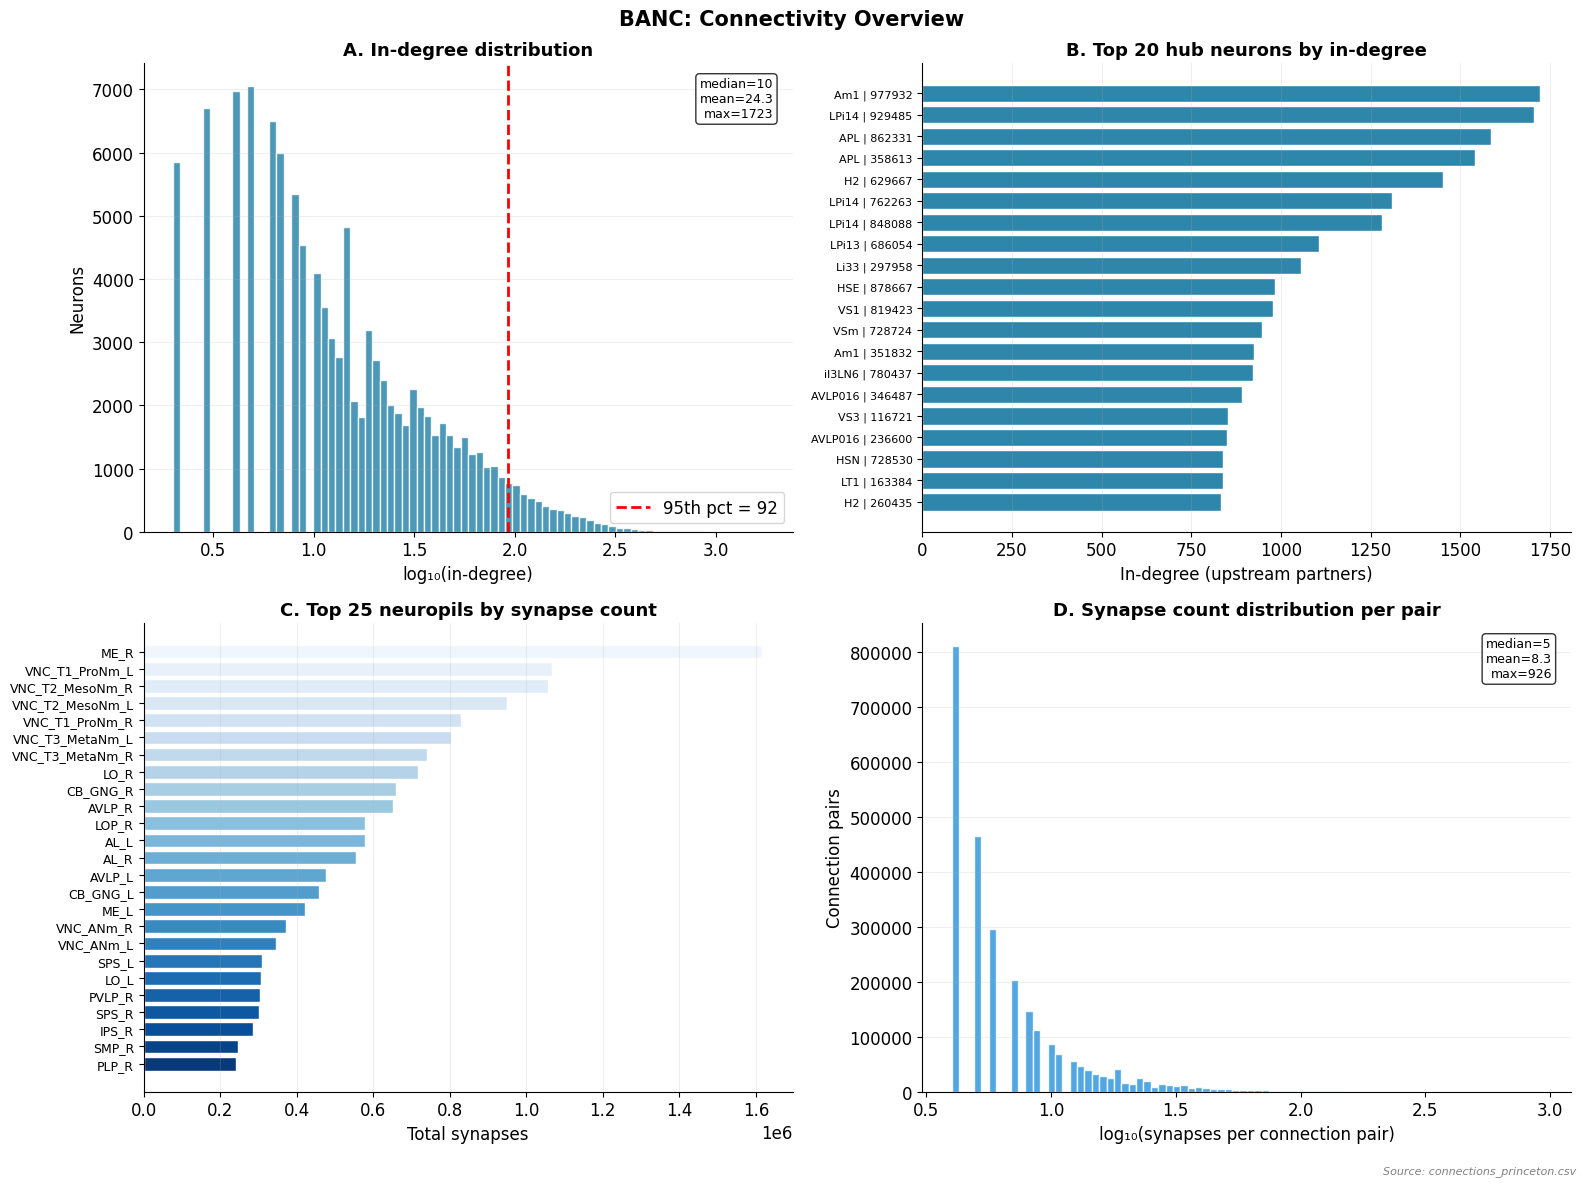

In [17]:
if not HAS_CONN:
    print('Connections not loaded — skipping Section 6.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    p95 = neurons[neurons['in_degree']>0]['in_degree'].quantile(0.95)

    # A: In-degree distribution
    ax = axes[0, 0]
    in_data = neurons[neurons['in_degree']>0]['in_degree']
    ax.hist(np.log10(in_data+1), bins=80, color=DATASET_COLOR, edgecolor='white', alpha=0.85)
    ax.axvline(np.log10(p95+1), color='red', linestyle='--', linewidth=2,
               label=f'95th pct = {p95:.0f}')
    ax.set_xlabel('log₁₀(in-degree)'); ax.set_ylabel('Neurons')
    ax.set_title('A. In-degree distribution', fontweight='bold')
    ax.text(0.97, 0.97,
            f'median={in_data.median():.0f}\nmean={in_data.mean():.1f}\nmax={in_data.max():.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(); ax.grid(True, axis='y', alpha=0.2)

    # B: Top 20 hub neurons by in-degree
    ax = axes[0, 1]
    hubs = neurons.nlargest(20, 'in_degree')
    label_col = next((c for c in ['primary_type','class','super_class']
                      if c in hubs.columns and hubs[c].notna().any()), None)
    hub_labels = (
        hubs[label_col].fillna('?').str[:20] + ' | ' + hubs['root_id'].astype(str).str[-6:]
    ).values if label_col else hubs['root_id'].astype(str).str[-12:].values
    ax.barh(hub_labels[::-1], hubs['in_degree'].values[::-1],
            color=DATASET_COLOR, edgecolor='white')
    ax.set_xlabel('In-degree (upstream partners)')
    ax.set_title('B. Top 20 hub neurons by in-degree', fontweight='bold')
    ax.tick_params(axis='y', labelsize=8); ax.grid(True, axis='x', alpha=0.2)

    # C: Top 25 neuropils by synapse count
    ax = axes[1, 0]
    if 'neuropil' in connections.columns:
        np_syn = connections.groupby('neuropil')['syn_count'].sum().nlargest(25)
        ax.barh(np_syn.index[::-1], np_syn.values[::-1],
                color=sns.color_palette('Blues_r', len(np_syn)), edgecolor='white')
        ax.set_xlabel('Total synapses')
        ax.set_title('C. Top 25 neuropils by synapse count', fontweight='bold')
        ax.tick_params(axis='y', labelsize=9); ax.grid(True, axis='x', alpha=0.2)

    # D: Synapse count per connection pair
    ax = axes[1, 1]
    pair_syn = connections.groupby(['pre_root_id','post_root_id'])['syn_count'].sum()
    ax.hist(np.log10(pair_syn+1), bins=80, color='#3498DB', edgecolor='white', alpha=0.85)
    ax.set_xlabel('log₁₀(synapses per connection pair)')
    ax.set_ylabel('Connection pairs')
    ax.set_title('D. Synapse count distribution per pair', fontweight='bold')
    ax.text(0.97, 0.97,
            f'median={pair_syn.median():.0f}\nmean={pair_syn.mean():.1f}\nmax={pair_syn.max():.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, axis='y', alpha=0.2)

    plt.suptitle('BANC: Connectivity Overview', fontsize=15, fontweight='bold')
    src('connections_princeton.csv')
    plt.tight_layout(rect=[0,0.02,1,1])
    plt.savefig('eda_outputs/08_connectivity_overview.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Connectivity Overview

This figure characterises the wiring structure of the BANC connectome — how connected neurons are, which ones are the biggest hubs, where synapses are concentrated anatomically, and how strong individual connections tend to be.

### Panel A — In-degree distribution
**In-degree** = the number of distinct upstream neurons sending input to a given neuron. The distribution is right-skewed with a long tail — most neurons are sparsely connected local processors while a small elite of hubs integrate signals from across the CNS. Key numbers: **median = 10**, **mean = 24.3**, **max = 1,723**. The 95th percentile sits at 92 (red dashed line), meaning only 5% of neurons have more than 92 upstream partners. Compared to FAFB (median = 15, max = 6,261), BANC neurons are on average less connected — consistent with the VNC containing many stereotyped sensory neurons with few upstream inputs.

### Panel B — Top 20 hub neurons by in-degree
The two most connected neurons are **Am1** (1,732 upstream partners) and **LPi14** (1,579) — amacrine and lobula plate interneurons from the optic lobe's motion processing circuit. **APL** appears twice (862 and 358 upstream partners) — the All-neurons Projecting to the Lobes neuron, a GABAergic feedback interneuron that blankets the mushroom body and is one of the most highly connected neurons in any fly connectome. **H2** (629), **LPi13/14**, **Li33**, **HSE**, and **VS1/VSm** are all visual motion neurons from the lobula plate, consistent with the optic lobe's dense recurrent connectivity. **AVLP016** and **HSN** are central brain and sensory neurons respectively. The dominance of optic lobe and central brain neurons in the top 20 reflects that VNC neurons, while numerous, tend toward lower in-degrees.

### Panel C — Top 25 neuropils by synapse count
**ME_R** (Medulla, right) is the most synapse-dense region by a large margin — consistent with the optic lobe's dominance in neuron count. Strikingly, the next six entries are all **VNC neuropils**: VNC_T1_ProNm (prothoracic leg neuromere), VNC_T2_MesoNm (mesothoracic), and VNC_T3_MetaNm (metathoracic), each on both sides. This is a direct BANC-specific finding with no FAFB equivalent — the leg neuromeres of the VNC collectively rival the brain's visual neuropils in synapse density, reflecting the intensive local computation needed for walking coordination. Brain neuropils follow: LO_R/L (lobula), CB_GNG (central brain + gnathal ganglia), AVLP, AL (antennal lobe). The left-right symmetry of paired neuropils is a data quality check — ME_R slightly exceeds ME_L, consistent with known minor asymmetries in optic lobe annotation completeness.

### Panel D — Synapse count per connection pair
When two neurons are connected, how strong is that connection? **Median = 5 synapses**, **mean = 8.3**, **max = 926**. The distribution is heavily left-skewed — the vast majority of connected pairs share only 3–10 synapses (the minimum threshold is 3), while strong connections with 50+ synapses are rare. This means synapse count (connection weight) varies enormously and should be considered when interpreting connectivity — not all connections in the table are biologically equivalent.

### Key takeaways
- BANC neurons are on average less connected than FAFB (median in-degree 10 vs 15), driven by the many sparse sensory neurons in the VNC
- VNC leg neuromeres are among the most synapse-dense regions in the entire CNS — a finding invisible in brain-only datasets
- Hub neurons are dominated by visual motion processing interneurons, with APL being the only mushroom body neuron in the top 20
- Most connections are weak (3–10 synapses); filtering to ≥10 or ≥20 synapses is advisable for analyses focused on functionally strong connections

In [24]:
if not HAS_CONN:
    print('Connections not loaded — skipping degree scatter.')
else:
    # INTERACTIVE: in vs out-degree scatter
    both = neurons[(neurons['in_degree']>0) & (neurons['out_degree']>0)].copy()
    s    = both.sample(min(8000, len(both)), random_state=42).copy()

    label_col = next((c for c in ['primary_type','class','super_class']
                      if c in s.columns and s[c].notna().any()), None)

    s['_label']     = s[label_col].fillna('?')             if label_col            else '?'
    s['_nt']        = s['nt_type'].fillna('?')              if 'nt_type'   in s.columns else '?'
    s['_body_part'] = s['body_part'].fillna('not annotated') if 'body_part' in s.columns else 'not annotated'
    s['_id']        = s['root_id'].astype(str)

    color_col = 'super_class' if 'super_class' in s.columns else None

    fig = px.scatter(
        s, x='in_degree', y='out_degree',
        color=color_col,
        color_discrete_map={k.lower().replace(' ','_'): v for k,v in PALETTE.items()},
        opacity=0.4, log_x=True, log_y=True,
        title='BANC: In-degree vs out-degree — hover to identify neurons<br>'
              '<sub>Source: connections_princeton.csv, neurons.csv</sub>',
        labels={'in_degree':'In-degree','out_degree':'Out-degree',
                'super_class':'Super-class'},
        custom_data=['_label','_id','_nt','_body_part','in_strength'],
        height=580
    )
    fig.update_traces(
        marker_size=4,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Root ID: %{customdata[1]}<br>'
            'NT type: %{customdata[2]}<br>'
            'Body part: %{customdata[3]}<br>'
            'In-degree: %{x:,}<br>'
            'Out-degree: %{y:,}<br>'
            'In-strength (synapses): %{customdata[4]:,}'
            '<extra></extra>'
        )
    )
    fig.update_layout(legend=dict(itemsizing='constant'))
    fig.write_html('eda_outputs/09_degree_scatter.html', include_plotlyjs='cdn')
    fig.show()
    print('Saved: eda_outputs/09_degree_scatter.html')

Saved: eda_outputs/09_degree_scatter.html


## In-degree vs Out-degree Scatter *(Interactive)*

This scatter plot places every neuron at the intersection of two connectivity measures: **in-degree** (x-axis, how many distinct neurons send input to it) and **out-degree** (y-axis, how many distinct neurons it sends output to). Both axes are log scale. A neuron's position reveals its functional role — whether it mainly receives, mainly broadcasts, does both, or neither.

### How to read it
- **Further right** = more upstream partners (receives from many neurons)
- **Higher up** = more downstream partners (sends to many neurons)
- **Top-right corner** = hub neurons that both receive and broadcast widely
- **Bottom-right** = integrators — receive from many, send to few
- **Top-left** = broadcasters — receive from few, send to many
- **Bottom-left** = peripheral neurons with sparse connections in both directions
- Both axes are **log scale** — each grid line is a 10× increase, not a fixed step

### How to use the interactivity
- **Hover over any dot** to see: cell type, root ID, NT type, body part, in-degree, out-degree, and total incoming synapse strength
- **Body part shows "not annotated"** for most neurons — only 11.7% of BANC neurons have a body part label, so this field is only populated for annotated peripheral sensory neurons
- **Click and drag** to zoom into any dense region
- **Click a super-class in the legend** to hide or show that group
- **Double-click the legend** to reset all groups to visible

### What the plot shows

**The main diagonal trend** confirms that in-degree and out-degree are broadly correlated — neurons that receive a lot tend to send a lot, a general property of biological neural networks.

**Sensory neurons (dark green) cluster along the left edge** at very low in-degree (1–5) with a wide range of out-degrees. These neurons receive from very few upstream sources (essentially just the physical stimulus) but fan out to many downstream targets.

**Central brain intrinsic neurons (teal) dominate the upper-right cloud** — high in-degree and high out-degree — consistent with their role as multi-input, multi-output integrators.

**VNC intrinsic neurons (light orange) form a dense mid-field cluster** with moderate in and out-degrees, reflecting the structured, repeating neuromere architecture where each neuron has a defined local role.

**Optic lobe intrinsic neurons (light blue) cluster in the middle** — moderate connectivity in both directions, consistent with the uniform column-based visual processing architecture.

**Descending neurons (salmon) sit above the diagonal** — they receive from a defined brain input layer and broadcast widely to VNC targets, the signature of a command neuron.

**The extreme top-right outliers** are the same hub neurons identified in the connectivity overview — Am1, APL, LPi14 — visually isolated far from the main cloud.

### Key takeaways
- A neuron's **position relative to the diagonal** reveals its role: above = broadcaster, below = integrator
- The `root_id` in the hover is your direct link to further analysis — copy it to look up the neuron in Codex or query it in your downstream notebook
- Use this plot to shortlist candidates: neurons with unusually high out-degree for their in-degree are potential command or broadcast neurons worth investigating

In [19]:
if not HAS_CONN:
    print('Connections not loaded — skipping NT heatmap.')
else:
    # INTERACTIVE: pre × post NT synapse heatmap
    nt_map  = neurons.set_index('root_id')['nt_type'].to_dict()
    conn2   = connections.copy()
    conn2['pre_nt']  = conn2['pre_root_id'].map(nt_map)
    conn2['post_nt'] = conn2['post_root_id'].map(nt_map)
    conn2 = conn2.dropna(subset=['pre_nt','post_nt'])
    conn2 = conn2[conn2['pre_nt'].isin(NT_COLORS) & conn2['post_nt'].isin(NT_COLORS)]
    hm = conn2.groupby(['pre_nt','post_nt'])['syn_count'].sum().unstack(fill_value=0)
    order = hm.sum(axis=1).sort_values(ascending=False).index
    hm = hm.reindex(index=order, columns=order, fill_value=0)
    fig = px.imshow(
        np.log10(hm+1), color_continuous_scale='Blues',
        title='BANC: Total synapses — pre-synaptic NT × post-synaptic NT (log₁₀)<br>'
              '<sub>Hover for exact synapse counts. Source: connections_princeton.csv</sub>',
        labels=dict(x='Post-synaptic NT', y='Pre-synaptic NT', color='log₁₀(synapses)'),
        text_auto='.1f', aspect='auto'
    )
    fig.update_traces(
        customdata=hm.values,
        hovertemplate='Pre: <b>%{y}</b> → Post: <b>%{x}</b><br>'
                      'Synapses: <b>%{customdata:,}</b><br>'
                      'log₁₀: %{z:.2f}<extra></extra>'
    )
    fig.update_layout(height=460, margin=dict(t=110,b=60,l=80,r=80))
    fig.write_html('eda_outputs/10_nt_synapse_heatmap.html', include_plotlyjs='cdn')
    fig.show()
    print('Saved: eda_outputs/10_nt_synapse_heatmap.html')

Saved: eda_outputs/10_nt_synapse_heatmap.html


## Pre × Post NT Synapse Heatmap *(Interactive)*

This heatmap maps the **total number of synapses flowing between every combination of neurotransmitter types** in the connectome. Each cell answers: across all connections where the sending neuron uses NT type X and the receiving neuron uses NT type Y, how many total synapses exist?

### How to read it
- **Rows** = pre-synaptic NT type (the sending neuron)
- **Columns** = post-synaptic NT type (the receiving neuron)
- **Cell colour and number** = log₁₀ of total synapse count — darker blue means more synapses
- The numbers are log scale: 6.8 means ~6.3 million synapses, 5.0 means ~100,000, 3.0 means ~1,000
- **Hover over any cell** to see the exact synapse count, the pre→post NT pair, and the log₁₀ value

### What the heatmap shows

**The top-left 3×3 block (ACH, GABA, GLUT) dominates** — these three NT types account for the vast majority of all synapses, consistent with their being the most numerous neuron types.

**ACH → ACH (6.8, ~6.3M synapses)** is the single largest cell — excitatory neurons talking to other excitatory neurons drives the bulk of information flow, as seen in FAFB.

**GABA → ACH (6.5) and GABA → GLUT (5.9)** are the next strongest — inhibitory GABA neurons heavily target excitatory types, consistent with GABA's role as a broad brake on circuit activity.

**GLUT → ACH (6.2) and GLUT → GLUT (5.7)** — glutamate, the second inhibitory type, also primarily targets excitatory neurons.

**The ACH row is uniformly dark across all columns** — excitatory ACH neurons send to every NT type, reflecting their role as the primary information-carrying neuron throughout the CNS.

**DA stands out with a high DA → DA value (4.7)** relative to its other entries — dopaminergic neurons have a notable self-targeting pattern, consistent with local dopaminergic feedback circuits in the mushroom body and VNC.

**SER, DA, OCT columns are much lighter** — modulatory neurotransmitters receive far fewer synapses, reflecting that neuromodulatory neurons are targets of relatively sparse, specific input rather than broad convergence.

**Compared to FAFB**, the overall pattern is similar but BANC shows stronger GLUT rows — consistent with BANC's higher inhibitory glutamate fraction driven by VNC motor circuits.

### Key takeaways
- The brain's synapse budget is heavily concentrated in ACH↔ACH, GABA→ACH, and GLUT→ACH — the core excitatory/inhibitory balancing acts
- **Hover is essential** — the log scale compresses a 10,000-fold range into similar-looking colours; two adjacent cells can differ by 10× in actual synapse count
- The strong GABA→ACH signal confirms that inhibitory neurons predominantly target excitatory ones — the expected motif for feedback inhibition
- Modulatory rows (SER, DA, OCT) have 100–1,000× fewer synapses than the major three — keep this in mind when comparing connection counts across NT types


## 7 — Inhibitory Neuron Deep-Dive
**Source: `neurons.csv`, `connections_princeton.csv`**

Panels A–C are directly comparable with FAFB. Panel D (inhibitory by body part) is BANC-specific.

Inhibitory (GABA+Glut): 35,766 (31.1%)
Excitatory (ACh):       65,367 (56.8%)


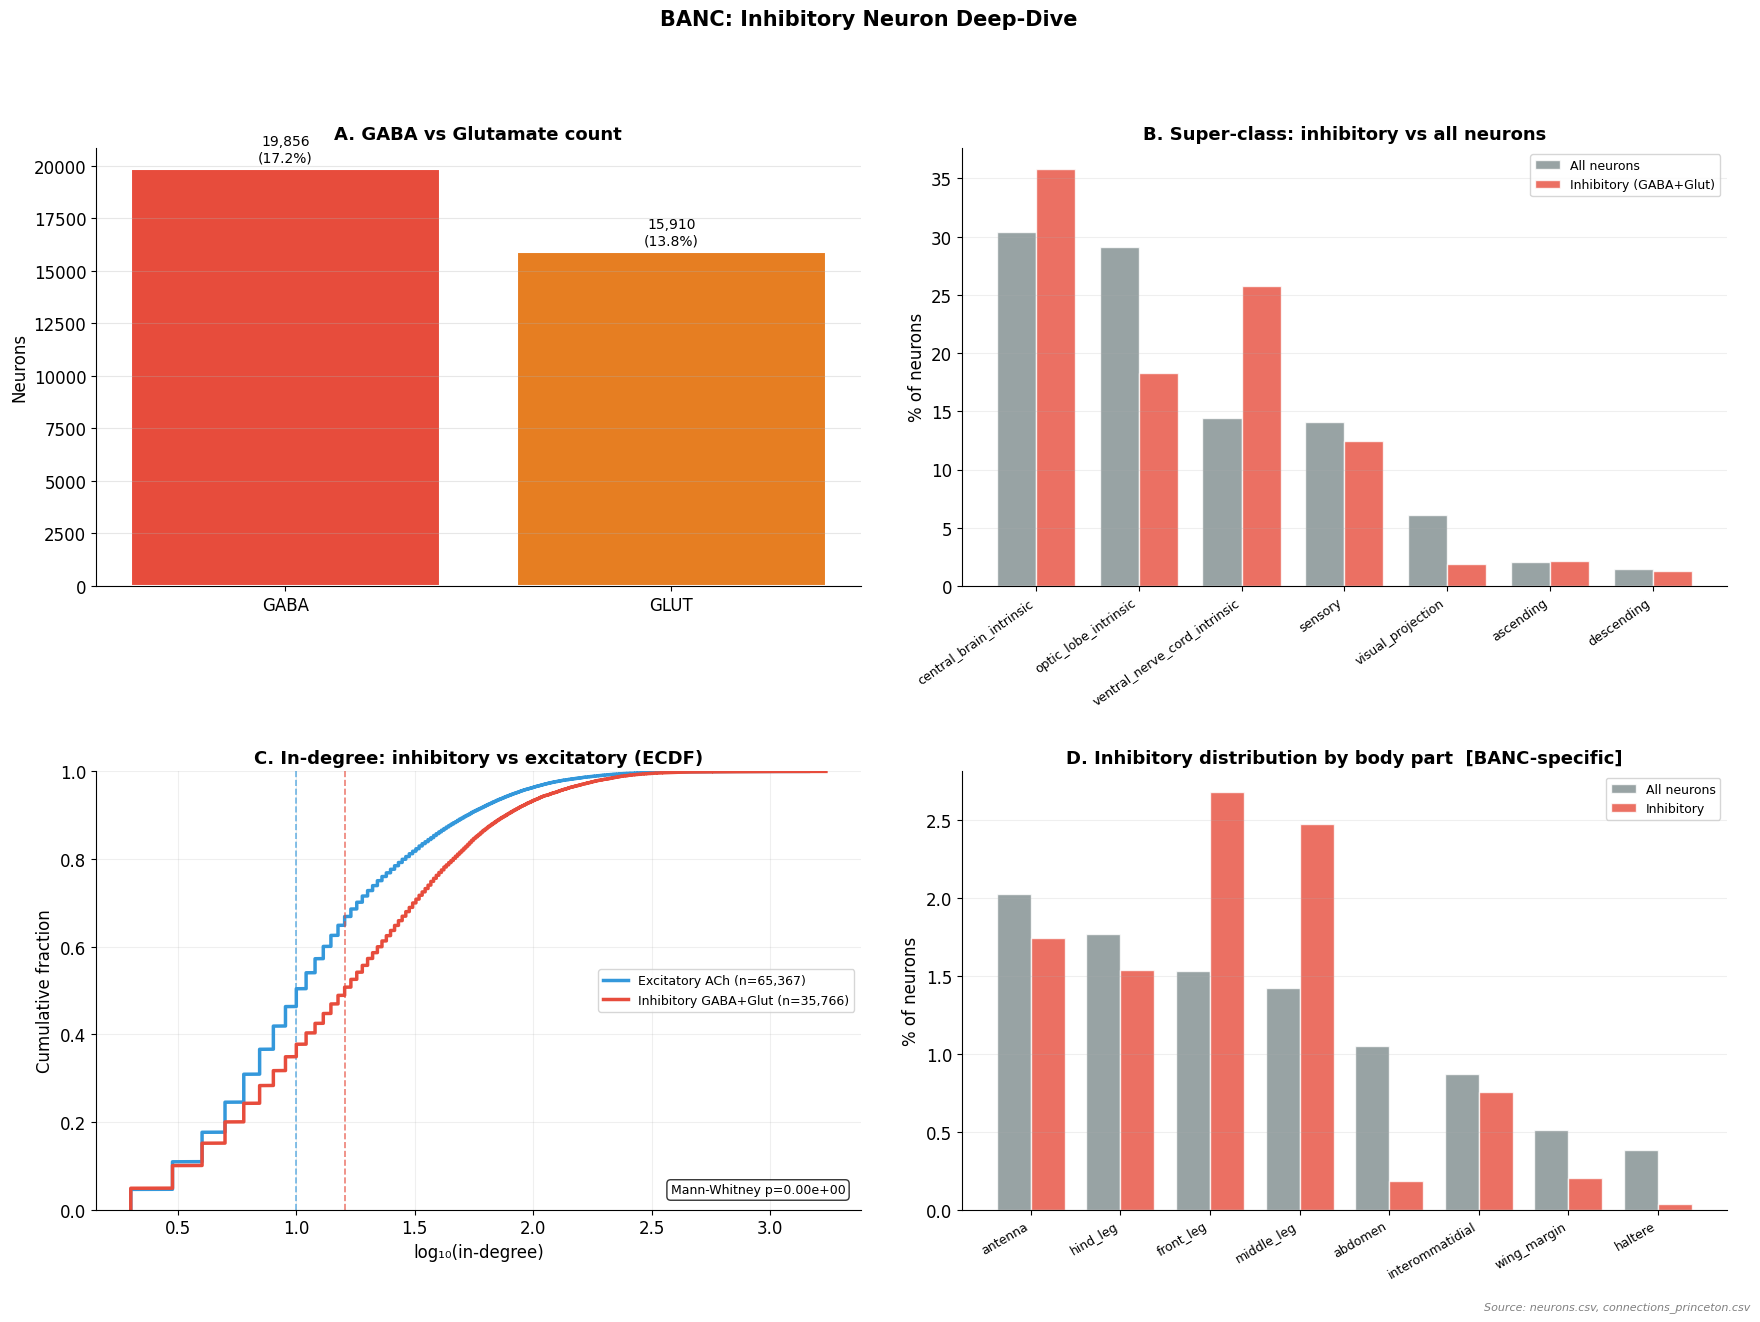

In [20]:
inhib = neurons[neurons['nt_type'].isin(INHIBITORY)]
excit = neurons[neurons['nt_type'].isin(EXCITATORY)]
print(f'Inhibitory (GABA+Glut): {len(inhib):,} ({100*len(inhib)/N:.1f}%)')
print(f'Excitatory (ACh):       {len(excit):,} ({100*len(excit)/N:.1f}%)')

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# A: GABA vs Glutamate count
ax = axes[0, 0]
for i, (nt, col) in enumerate([('GABA','#E74C3C'),('GLUT','#E67E22')]):
    cnt = (neurons['nt_type']==nt).sum()
    ax.bar(nt, cnt, color=col, edgecolor='white', linewidth=1.5)
    ax.text(i, cnt+N*0.003, f'{cnt:,}\n({100*cnt/N:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Neurons'); ax.set_title('A. GABA vs Glutamate count', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# B: Super-class composition — inhibitory vs all
ax = axes[0, 1]
if 'super_class' in neurons.columns:
    sc_all   = neurons['super_class'].value_counts(normalize=True)*100
    sc_inhib = inhib['super_class'].value_counts(normalize=True)*100
    sc_ord   = sc_all.head(7).index
    x = np.arange(len(sc_ord)); w = 0.38
    ax.bar(x-w/2, [sc_all.get(s,0)   for s in sc_ord], w, color='#7F8C8D',
           alpha=0.8, label='All neurons', edgecolor='white')
    ax.bar(x+w/2, [sc_inhib.get(s,0) for s in sc_ord], w, color='#E74C3C',
           alpha=0.8, label='Inhibitory (GABA+Glut)', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(sc_ord, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('% of neurons')
    ax.set_title('B. Super-class: inhibitory vs all neurons', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

# C: In-degree ECDF comparison
ax = axes[1, 0]
if HAS_CONN and 'in_degree' in neurons.columns:
    for data, color, label in [
        (excit[excit['in_degree']>0]['in_degree'], '#3498DB',
         f'Excitatory ACh (n={len(excit):,})'),
        (inhib[inhib['in_degree']>0]['in_degree'], '#E74C3C',
         f'Inhibitory GABA+Glut (n={len(inhib):,})'),
    ]:
        sorted_d = np.sort(np.log10(data+1))
        y = np.arange(1, len(sorted_d)+1) / len(sorted_d)
        ax.plot(sorted_d, y, color=color, linewidth=2.5, label=label)
        ax.axvline(np.log10(data.median()+1), color=color,
                   linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_xlabel('log₁₀(in-degree)'); ax.set_ylabel('Cumulative fraction')
    ax.set_title('C. In-degree: inhibitory vs excitatory (ECDF)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2); ax.set_ylim(0,1)
    u, p = stats.mannwhitneyu(
        inhib[inhib['in_degree']>0]['in_degree'],
        excit[excit['in_degree']>0]['in_degree'], alternative='two-sided')
    ax.text(0.98, 0.03, f'Mann-Whitney p={p:.2e}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'Degree data\nnot available', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=12)
    ax.set_title('C. In-degree: inhibitory vs excitatory (ECDF)', fontweight='bold')

# D: Inhibitory by body part [BANC-specific]
ax = axes[1, 1]
if 'body_part' in neurons.columns:
    top_bp   = neurons['body_part'].value_counts().head(8).index
    inhib_bp = inhib[inhib['body_part'].isin(top_bp)]['body_part'].value_counts()
    all_bp   = neurons[neurons['body_part'].isin(top_bp)]['body_part'].value_counts()
    x = np.arange(len(top_bp)); w = 0.38
    ax.bar(x-w/2, [100*all_bp.get(p,0)/N            for p in top_bp], w,
           color='#7F8C8D', alpha=0.8, label='All neurons', edgecolor='white')
    ax.bar(x+w/2, [100*inhib_bp.get(p,0)/len(inhib) for p in top_bp], w,
           color='#E74C3C', alpha=0.8, label='Inhibitory', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(top_bp, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('% of neurons')
    ax.set_title('D. Inhibitory distribution by body part  [BANC-specific]', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)
else:
    ax.text(0.5, 0.5, 'body_part column\nnot available', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=12)
    ax.set_title('D. Inhibitory: by body part', fontweight='bold')

plt.suptitle('BANC: Inhibitory Neuron Deep-Dive', fontsize=15, fontweight='bold', y=1.01)
src('neurons.csv, connections_princeton.csv')
plt.tight_layout(pad=2.5)
plt.savefig('eda_outputs/11_inhibitory_deepdive.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Inhibitory Neuron Deep-Dive

This figure zooms in on the **35,766 inhibitory neurons** (GABA + Glutamate combined, 31.1% of all neurons) and asks how they differ from the rest of the brain in terms of abundance, distribution across super-classes, connectivity, and anatomical location.

### Panel A — GABA vs Glutamate count
There are two distinct inhibitory types: **GABA** (19,856, 17.2%) and **Glutamate** (15,910, 13.8%). GABA slightly outnumbers GLUT, though both are substantial populations. Combined they make up nearly one in three neurons — a higher inhibitory fraction than FAFB's 25.6%, driven by the VNC's motor coordination demands. It is worth distinguishing these two types in analysis rather than treating all inhibitory neurons as a single group, as they have distinct connectivity profiles and circuit roles.

### Panel B — Super-class: inhibitory vs all neurons
Comparing the super-class distribution of inhibitory neurons (red) against all neurons (grey) reveals where inhibition is enriched or depleted:

- **Optic_lobe_intrinsic**: strongly *overrepresented* in inhibitory neurons (~36% of inhibitory vs ~22% of all) — the visual system uses inhibition heavily for motion detection, contrast enhancement, and direction selectivity
- **VNC_intrinsic**: strongly *overrepresented* (~26% of inhibitory vs ~11% of all) — the VNC's motor circuits require dense inhibitory interneurons to coordinate alternating leg movements and suppress unwanted muscle activation. This is the key difference from FAFB
- **Central_brain_intrinsic**: *underrepresented* (~18% of inhibitory vs ~30% of all) — perhaps counterintuitively, the central brain has proportionally fewer inhibitory neurons than its overall size would suggest
- **Sensory**: *underrepresented* (~13% vs ~14%) — sensory input neurons are predominantly excitatory, relaying signals forward
- **Visual_projection, ascending, descending**: all near zero in inhibitory — long-range projection neurons are almost exclusively excitatory

### Panel C — In-degree ECDF: inhibitory vs excitatory
This cumulative distribution shows what fraction of neurons have an in-degree at or below each value. The **inhibitory curve (red) is shifted to the right** relative to excitatory (blue) — inhibitory neurons receive input from more upstream partners on average. The median in-degree is slightly higher for inhibitory neurons (dashed red line) than excitatory (dashed blue line). The **Mann-Whitney p=0.00** confirms this difference is statistically significant across the full population. Inhibitory neurons in BANC are not peripheral modulators — they are well-connected central elements receiving broad convergent input, consistent with their role as circuit-level controllers rather than simple gatekeepers.

### Panel D — Inhibitory distribution by body part *(BANC-specific)*
This panel has no FAFB equivalent. Comparing inhibitory (red) vs all neurons (grey) as a percentage of total neurons across the top body parts:

- **Middle_leg and front_leg** show the strongest inhibitory enrichment — inhibitory neurons are disproportionately concentrated in leg neuromeres, consistent with the need for strong inter-leg inhibition during walking
- **Hind_leg** shows a similar but slightly weaker enrichment
- **Antenna** has slightly fewer inhibitory neurons relative to its overall proportion — olfactory and mechanosensory antenna neurons are predominantly excitatory
- **Abdomen and interommatidial** show inhibitory *depletion* — these regions are dominated by sensory input neurons that are mostly excitatory
- **Wing_margin and haltere** have very few inhibitory neurons in either group, consistent with these being primarily sensory afferent structures

### Key takeaways
- BANC's higher inhibitory fraction (31.1% vs FAFB's 25.6%) is largely driven by VNC motor circuitry — filter to `super_class != 'ventral_nerve_cord_intrinsic'` to compare the brain-only inhibitory fraction more fairly with FAFB
- Inhibitory neurons receive from more upstream partners than excitatory ones — they are highly connected integrators, not peripheral suppressors
- Leg neuromeres are the most inhibitory-enriched body parts, directly reflecting the bilateral inhibitory circuits that coordinate walking
- Distinguish GABA from GLUT in any inhibitory analysis — they are similarly abundant but occupy different circuit roles


## 8 — Exploration Dashboard  *(Interactive HTML)*

To add FAFB for side-by-side comparison, load it with its own `DATA_DIR`, build `fafb_neurons` and `fafb_connections`, then append them to `ALL_NEURONS`, `ALL_CONNECTIONS`, `ALL_CONFIGS` before calling `build_comparison_dashboard`.

In [21]:
BANC_CONFIG = {'name': 'BANC', 'color': '#2E86AB'}

ALL_NEURONS     = [neurons]
ALL_CONNECTIONS = [connections] if HAS_CONN else [pd.DataFrame()]
ALL_CONFIGS     = [BANC_CONFIG]

def build_comparison_dashboard(
    all_neurons, all_connections, all_configs,
    save_path='eda_outputs/12_comparison_dashboard.html'
):
    datasets    = [cfg['name'] for cfg in all_configs]
    neurons_all = pd.concat(all_neurons, ignore_index=True)

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            'A. In-degree distribution (log scale)',
            'B. NT type proportions',
            'C. Median in-degree by NT type',
            'D. Annotation completeness',
            'E. In-degree vs out-degree (hover to identify)',
            'F. Top cell classes',
        ],
        vertical_spacing=0.12, horizontal_spacing=0.10,
        specs=[
            [{'type':'xy'},      {'type':'bar'}],
            [{'type':'bar'},     {'type':'heatmap'}],
            [{'type':'scatter'}, {'type':'bar'}],
        ]
    )

    nt_types = (
        neurons_all['nt_type'].value_counts()
        .drop('Unknown', errors='ignore').dropna().index.tolist()
    ) if 'nt_type' in neurons_all.columns else []

    for ndf, cdf, cfg in zip(all_neurons, all_connections, all_configs):
        name   = cfg['name']
        col    = cfg['color']
        id_col = 'root_id' if 'root_id' in ndf.columns else ndf.columns[0]

        # A: In-degree distribution
        if 'in_degree' in ndf.columns:
            in_data = ndf[ndf['in_degree']>0]['in_degree']
            fig.add_trace(go.Histogram(
                x=np.log10(in_data+1), nbinsx=70, name=name,
                opacity=0.65, marker_color=col, legendgroup=name, showlegend=True,
                histnorm='probability density',
                hovertemplate=f'<b>{name}</b><br>log₁₀(in-degree): %{{x:.2f}}<extra></extra>'
            ), row=1, col=1)

        # B: NT proportions
        if 'nt_type' in ndf.columns and nt_types:
            nt_pct = ndf['nt_type'].value_counts(normalize=True)*100
            fig.add_trace(go.Bar(
                x=nt_types, y=[nt_pct.get(nt,0) for nt in nt_types],
                name=name, marker_color=col, legendgroup=name, showlegend=False,
                hovertemplate=f'<b>{name}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
            ), row=1, col=2)

        # C: Median in-degree by NT type
        if 'nt_type' in ndf.columns and 'in_degree' in ndf.columns and nt_types:
            med = (ndf[ndf['in_degree']>0].groupby('nt_type')['in_degree']
                   .median().drop('Unknown', errors='ignore').reindex(nt_types))
            fig.add_trace(go.Bar(
                x=nt_types, y=med.values, name=name, marker_color=col,
                legendgroup=name, showlegend=False,
                hovertemplate=f'<b>{name}</b><br>%{{x}}: median=%{{y:.0f}}<extra></extra>'
            ), row=2, col=1)

        # E: In vs out-degree scatter
        if 'in_degree' in ndf.columns and 'out_degree' in ndf.columns:
            both = ndf[(ndf['in_degree']>0) & (ndf['out_degree']>0)]
            s    = both.sample(min(3000, len(both)), random_state=42)
            label_col = next(
                (c for c in ['primary_type','class','super_class']
                 if c in s.columns and s[c].notna().any()), None)
            hover_label = s[label_col].fillna('?') if label_col else pd.Series(['?']*len(s), index=s.index)
            nt_hover    = s['nt_type'].fillna('?')   if 'nt_type'   in s.columns else pd.Series(['?']*len(s), index=s.index)
            bp_hover    = s['body_part'].fillna('?') if 'body_part' in s.columns else pd.Series(['?']*len(s), index=s.index)
            fig.add_trace(go.Scatter(
                x=s['in_degree'], y=s['out_degree'], mode='markers',
                marker=dict(color=col, size=4, opacity=0.35),
                name=name, legendgroup=name, showlegend=False,
                customdata=np.stack([hover_label, s[id_col].astype(str), nt_hover, bp_hover], axis=1),
                hovertemplate=(
                    f'<b>{name}</b><br>Type: %{{customdata[0]}}<br>'
                    'ID: %{customdata[1]}<br>NT: %{customdata[2]}<br>'
                    'Body part: %{customdata[3]}<br>In: %{x:,}  Out: %{y:,}<extra></extra>'
                )
            ), row=3, col=1)

        # F: Top cell classes
        class_col = 'class' if 'class' in ndf.columns else None
        if class_col and ndf[class_col].notna().any():
            top_cc = neurons_all[class_col].value_counts().dropna().head(10).index.tolist()
            cc_pct = ndf[class_col].value_counts(normalize=True)*100
            fig.add_trace(go.Bar(
                x=top_cc, y=[cc_pct.get(c,0) for c in top_cc],
                name=name, marker_color=col, legendgroup=name, showlegend=False,
                hovertemplate=f'<b>{name}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
            ), row=3, col=2)

    # D: Annotation completeness heatmap
    ann_fields = ['super_class','class','primary_type','nt_type',
                  'verified_nt','body_part','side','flow','hemilineage']
    ann_fields = [f for f in ann_fields if f in neurons_all.columns]
    hm_z = [[round(100*ndf[f].notna().mean(), 1) if f in ndf.columns else 0
              for f in ann_fields] for ndf in all_neurons]
    fig.add_trace(go.Heatmap(
        z=hm_z, x=ann_fields, y=datasets,
        colorscale='Greens', zmin=0, zmax=100,
        text=[[f'{v:.0f}%' for v in row] for row in hm_z],
        texttemplate='%{text}',
        colorbar=dict(title='% annotated', len=0.28, y=0.5),
        hovertemplate='<b>%{y}</b><br>%{x}: %{z:.1f}% annotated<extra></extra>'
    ), row=2, col=2)

    fig.update_xaxes(title_text='log₁₀(in-degree)',    row=1, col=1)
    fig.update_yaxes(title_text='Probability density', row=1, col=1)
    fig.update_xaxes(title_text='Neurotransmitter',    row=1, col=2)
    fig.update_yaxes(title_text='% of neurons',        row=1, col=2)
    fig.update_xaxes(title_text='Neurotransmitter',    row=2, col=1)
    fig.update_yaxes(title_text='Median in-degree',    row=2, col=1)
    fig.update_xaxes(title_text='In-degree',  type='log', row=3, col=1)
    fig.update_yaxes(title_text='Out-degree', type='log', row=3, col=1)
    fig.update_xaxes(title_text='Cell class', tickangle=35, row=3, col=2)
    fig.update_yaxes(title_text='% of neurons',        row=3, col=2)

    fig.update_layout(
        title=dict(
            text=('BANC — Exploration Dashboard<br><sub>'
                  + ', '.join(datasets)
                  + '  ·  Click legend to toggle  ·  Hover for details  ·  Drag to zoom</sub>'),
            x=0.5, font=dict(size=17)
        ),
        height=1380, barmode='group', template='plotly_white',
        legend=dict(title='Dataset', orientation='h',
                    yanchor='bottom', y=1.02, xanchor='left', x=0.0,
                    font=dict(size=13)),
        margin=dict(t=130, b=60, l=80, r=80),
    )
    fig.write_html(save_path, include_plotlyjs='cdn')
    print(f'\n✓ Dashboard saved: {save_path}')
    fig.show()
    return fig

dashboard = build_comparison_dashboard(ALL_NEURONS, ALL_CONNECTIONS, ALL_CONFIGS)


✓ Dashboard saved: eda_outputs/12_comparison_dashboard.html


## Exploration Dashboard *(Interactive HTML)*

### What this dashboard is
This is a **6-panel interactive summary** of the BANC dataset designed as the primary exploration and comparison tool. When FAFB (or any other dataset) is registered alongside BANC, every panel will automatically show both datasets side by side — the legend lets you toggle each on and off simultaneously across all panels. Right now it reflects BANC alone.

---

### How to use it
- **Hover** over any bar, point, or heatmap cell for exact values
- **Click a dataset name in the legend** to hide or show it across all panels at once — this is most powerful once a second dataset is added
- **Double-click the legend** to isolate a single dataset
- **Click and drag** on Panel E to zoom into a specific connectivity range; double-click to reset
- The dashboard is a **self-contained HTML file** — share it with anyone and it opens in any browser with no software needed

---

### Panel A — In-degree distribution (log scale)
Shows the full distribution of how many upstream partners each neuron has. The characteristic right-skewed shape — peaking around log₁₀ = 0.8–1.0 (roughly 6–10 upstream partners) with a long tail extending to log₁₀ = 3+ — is the fingerprint of a biological neural network. Most neurons are sparsely connected local processors, while a small elite of hubs integrate signals from across the CNS. When FAFB is added, its distribution will overlay in purple, immediately revealing whether the two datasets have comparable connectivity profiles.

### Panel B — NT type proportions
A grouped bar chart showing what percentage of neurons use each neurotransmitter. ACH dominates at ~57%, followed by GABA (~17%) and GLUT (~14%), with modulatory types barely visible. This panel will be most informative in cross-dataset comparison — FAFB's ~59% ACH and ~25.6% combined inhibitory fraction can be directly compared against BANC's higher inhibitory fraction of 31.1%.

### Panel C — Median in-degree by NT type
Asks whether different NT types have different connectivity levels. In BANC the pattern shows inhibitory types (GABA, GLUT) with higher median in-degrees than excitatory ACH — consistent with Panel C of the inhibitory deep-dive showing inhibitory neurons are well-connected integrators. Modulatory types (DA, SER, OCT) sit lower. When FAFB is added, differences in this pattern across datasets will reveal whether the connectivity advantage of inhibitory neurons is a universal feature or BANC-specific.

### Panel D — Annotation completeness heatmap
A **data quality scorecard** showing what percentage of neurons have a non-null value for each annotation field. Each cell shows coverage as a percentage — darker green means more complete. Key fields for BANC: `side` is near-complete, `nt_type` and `super_class` are strong, `body_part` and `hemilineage` are sparse. When FAFB is added as a second row, this panel immediately flags which fields exist in both datasets and can support cross-dataset comparisons — any field near 0% in one dataset cannot be used for comparison.

### Panel E — In-degree vs out-degree scatter
Each dot is a single neuron sampled from the full dataset, positioned by how many neurons send it input (x) and how many it sends output to (y), both on log scales. The diagonal trend confirms that connectivity is correlated across directions. Hover over any dot to see its cell type, root ID, NT type, and exact degree values. When FAFB is added in purple alongside BANC in blue, structural differences in how the two datasets wire their neurons will be immediately visible as shifts in the cloud positions.

### Panel F — Top cell classes
A grouped bar chart of the ten most numerous cell classes as a percentage of total neurons. BANC is currently dominated by `transverse_neuron`, `bristle_neuron`, and optic lobe types — a very different profile from what FAFB would show (dominated by `optic_lobe_intrinsic`). This panel makes population composition differences concrete in one glance.


## 9 — Summary Table

In [22]:
rows = [('Dataset', 'BANC (Brain And Nerve Cord)'), ('Total neurons', f'{N:,}')]

if HAS_CONN:
    rows += [
        ('Total connections (≥3 syn)', f'{len(connections):,}'),
        ('Total synapses',             f'{connections["syn_count"].sum():,}'),
    ]
    if 'neuropil' in connections.columns:
        rows.append(('Distinct neuropils', str(connections['neuropil'].nunique())))

for col in ['super_class','class','primary_type','nt_type','verified_nt',
            'body_part','side','flow','hemilineage']:
    if col in neurons.columns:
        valid = neurons[col].notna() &                 ~neurons[col].astype(str).str.strip().isin(['','nan','Unknown','None'])
        rows.append((f'{col} coverage', f'{100*valid.mean():.1f}%'))

if 'nt_type' in neurons.columns:
    nt_u = neurons['nt_type'].fillna('Unknown')
    ni = nt_u.isin(INHIBITORY).sum(); ne = nt_u.isin(EXCITATORY).sum()
    rows += [('Inhibitory (GABA+Glut)', f'{ni:,} ({100*ni/N:.1f}%)'),
             ('Excitatory (ACh)',       f'{ne:,} ({100*ne/N:.1f}%)')]

if HAS_CONN and 'in_degree' in neurons.columns:
    in_live = neurons[neurons['in_degree']>0]['in_degree']
    rows += [('In-degree: median',   f'{in_live.median():.0f}'),
             ('In-degree: 95th pct', f'{in_live.quantile(0.95):.0f}'),
             ('In-degree: max',      f'{in_live.max():.0f}')]

summary_df = pd.DataFrame(rows, columns=['Metric','Value'])
print('SUMMARY'); print('='*55)
for _, row in summary_df.iterrows():
    print(f'  {row["Metric"]:<38}  {row["Value"]}')
summary_df.to_csv('eda_outputs/summary.csv', index=False)
print('\nSaved: eda_outputs/summary.csv')

SUMMARY
  Dataset                                 BANC (Brain And Nerve Cord)
  Total neurons                           115,151
  Total connections (≥3 syn)              3,777,046
  Total synapses                          22,243,310
  Distinct neuropils                      114
  super_class coverage                    76.7%
  class coverage                          53.3%
  primary_type coverage                   76.1%
  nt_type coverage                        94.6%
  verified_nt coverage                    33.0%
  body_part coverage                      11.7%
  side coverage                           99.7%
  flow coverage                           76.3%
  hemilineage coverage                    37.6%
  Inhibitory (GABA+Glut)                  35,766 (31.1%)
  Excitatory (ACh)                        65,367 (56.8%)
  In-degree: median                       10
  In-degree: 95th pct                     92
  In-degree: max                          1723

Saved: eda_outputs/summary.csv



## 10 — Download All Outputs

In [23]:
import shutil
shutil.make_archive('eda_outputs', 'zip', 'eda_outputs')
from google.colab import files
files.download('eda_outputs.zip')

print('All outputs:')
for f in sorted(os.listdir('eda_outputs')):
    sz  = os.path.getsize(f'eda_outputs/{f}')
    fmt = ('HTML (interactive)' if f.endswith('.html') else
           'PDF (static)'       if f.endswith('.pdf')  else 'CSV')
    print(f'  {f:<55} {sz/1024:6.0f} KB  [{fmt}]')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All outputs:
  01_population_overview.pdf                                  32 KB  [PDF (static)]
  02_cell_hierarchy_treemap.html                              24 KB  [HTML (interactive)]
  03_nt_profile.pdf                                           34 KB  [PDF (static)]
  04_nt_confidence.pdf                                        35 KB  [PDF (static)]
  05_predicted_vs_verified_nt.html                            10 KB  [HTML (interactive)]
  06_cell_type_coverage.pdf                                   34 KB  [PDF (static)]
  07_body_part.pdf                                            37 KB  [PDF (static)]
  08_connectivity_overview.pdf                                39 KB  [PDF (static)]
  09_degree_scatter.html                                     332 KB  [HTML (interactive)]
  10_nt_synapse_heatmap.html                                  10 KB  [HTML (interactive)]
  11_inhibitory_deepdive.pdf                                  41 KB  [PDF (static)]
  12_comparison_dashboard.html         